# Pipeline Binário (50% vs 75%) — RandomForest + Regressão Logística + XGBoost, com CV Aninhada

**O que mudou em relação ao notebook original (`Pipeline_RF_LogReg_XGB.ipynb`):**

1. **Classificação binária, só 50% vs 75%** — os arquivos de condição 25% são removidos
   na etapa de limpeza (Seção 2). Os três modelos do notebook original continuam:
   **RandomForest**, **Regressão Logística** e **XGBoost**.
2. **CV aninhada (nested Leave-One-Rat-Out)** — no notebook original, a escolha de
   `passo_pct` + hiperparâmetros e a avaliação final usavam os **mesmos folds** de
   Leave-One-Rat-Out, o que infla um pouco a acurácia reportada. Aqui, para cada rato
   deixado de fora na avaliação final (**loop externo**), a escolha de configuração
   (`passo_pct`, com/sem seleção de features, hiperparâmetros) é feita usando **só os
   ratos de treino** desse fold, com outro Leave-One-Rat-Out **dentro** deles (**loop
   interno**). O rato de teste nunca influencia a escolha de configuração usada para
   avaliá-lo — inclusive a remoção de atributos correlacionados agora também é decidida
   só com dados de treino (ver `montar_dataset_treino_teste`).
3. **Grades de hiperparâmetros** — ampliadas nesta versão (mais valores de `passo_pct`
   e mais combinações de hiperparâmetros por modelo) para dar mais chance de achar uma
   configuração melhor. Isso deixa a execução mais lenta; os comentários no código
   indicam onde cortar de volta se ficar inviável no seu computador.
4. **`pasta_multiclasse` corrigido** — no notebook original essa variável nunca era
   definida (dava `NameError` ao tentar salvar). Aqui já vem definida na Seção 1.
5. **Teste de permutação simplificado** — refazer a seleção de configuração para cada
   permutação multiplicaria o custo de novo (por ~50-100x). Aqui o teste reaproveita a
   configuração já escolhida em cada fold externo (a mesma do resultado real) e só
   re-treina/reavalia com os rótulos embaralhados por arquivo. Isso é uma simplificação
   prática, documentada no código — deixe isso explícito se a professora perguntar.
6. **Seção 9 (comparação final + exportação dos resultados)** foi escrita — no notebook
   original essa seção só existia no sumário, não no código.
7. **Warning do sklearn (`sklearn.utils.parallel.delayed`...)** corrigido — o
   `RandomForestClassifier` usado por padrão *dentro do seletor de features*
   (`montar_pipeline_binaria`) ainda estava com `n_jobs=-1`; como ele roda dentro do
   `GridSearchCV` (que também usa `n_jobs=-1`), isso causava paralelismo aninhado, e
   é essa combinação específica que dispara o warning. Agora está `n_jobs=1`.



## 1. Configuração e Carregamento dos Dados

In [ ]:
print('oi')

In [ ]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [5]:
import json
import os
import time
import warnings
from pathlib import Path

os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # usado só como selector interno do SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.base import clone
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

try:
    import shap
    SHAP_DISPONIVEL = True
except ImportError:
    SHAP_DISPONIVEL = False
    print("Pacote 'shap' não encontrado. Instale com: pip install shap")

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIVEL = True
except ImportError:
    XGBOOST_DISPONIVEL = False
    print("Pacote 'xgboost' não encontrado. Instale com: pip install xgboost")

warnings.filterwarnings("ignore")
# Filtro extra (cinto e suspensório) para o warning de paralelismo aninhado do
# sklearn -- a causa real já foi corrigida (estimadores internos com n_jobs=1
# em vez de -1, evitando nested parallelism), isso aqui é só reforço.
warnings.filterwarnings("ignore", message=".*should be used with.*Parallel.*")
sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

TOP_N_FEATURES_GRID = [5, 10, 15, 20, 25]  # ampliado (mais opções de nº de atributos selecionados)

CAMINHOS_CANDIDATOS = [
    Path("../../ML/databases/features_all.csv"),
]

# Limite mínimo de duração do vídeo (segundos)
DURACAO_MINIMA_S = 30

FEATURE_BOOLEANA = "pac_sl_alerta"
FEATURES_POR_AREA = [
    "mean", "std", "rms", "kurtosis", "skewness", "pico_a_pico", "pct_outlier_3s",
    "pot_delta", "pot_theta", "pot_beta", "pot_gamma_lento", "pot_gamma_rapido",
    "theta_gamma_lento_ratio", "theta_gamma_rapido_ratio", "delta_theta_ratio",
    "entropia_espectral", "centroide_hz",
    "pac_theta-gamma_rapido", "pac_theta-gamma_lento", "pac_sl_alerta",
]

# Grade de "pct" (tamanho da janela percentual) testada na escolha do melhor.
# IMPORTANTE: só usamos valores que são divisores exatos de 100. A função
# montar_dataset_modelagem faz n_bins = round(100 / passo_pct); com valores que
# não dividem 100 exatamente isso gera bins tortos (ex.: passo_pct=30 ou 35
# viravam n_bins=3, ou seja, janelas de 33% em vez de 30%/35%) e também
# duplicava configurações (ex.: passo_pct=40 e 45 caíam ambos em n_bins=2,
# igual ao passo_pct=50 -- rodando o mesmo modelo 3x à toa). Com divisores
# exatos de 100 cada passo_pct vira um n_bins único e as janelas batem
# exatamente com o rótulo (5% é 5% mesmo, não 4.76%).
PASSO_PCT_GRID = [20]
print(f"Candidatos de passo_pct a testar: {PASSO_PCT_GRID}")
print(f"(n_bins correspondentes: {[round(100 / p) for p in PASSO_PCT_GRID]} -- "
      f"todos exatos, sem arredondamento)")

# Classificação binária: só 50% vs 75% (25% é removido na Seção 2)
CONDICOES_ALVO = [50, 75]

caminho_dados = next((p for p in CAMINHOS_CANDIDATOS if p.exists()), None)
if caminho_dados is None:
    raise FileNotFoundError(
        "features_all não encontrado. Ajuste CAMINHOS_CANDIDATOS para apontar "
        "para o seu features_all.parquet ou features_all.csv."
    )

if caminho_dados.suffix == ".parquet":
    df_bruto = pd.read_parquet(caminho_dados)
else:
    df_bruto = pd.read_csv(caminho_dados)

print(f" Carregado: {caminho_dados}")
print(f"   Shape: {df_bruto.shape[0]:,} linhas × {df_bruto.shape[1]} colunas")

# Pasta de saída -- CORRIGIDO: no notebook original esta variável nunca era
# definida, e o notebook dava NameError ao tentar salvar os resultados.
pasta_multiclasse = Path("resultados_tentativa")
pasta_multiclasse.mkdir(exist_ok=True)
print(f"   Resultados serão salvos em: {pasta_multiclasse.resolve()}")

Candidatos de passo_pct a testar: [20]
(n_bins correspondentes: [5] -- todos exatos, sem arredondamento)
 Carregado: ..\..\ML\databases\features_all.csv
   Shape: 19,028 linhas × 105 colunas
   Resultados serão salvos em: D:\analise_lfp\LAVID_SERVER\tentativa\resultados_tentativa


## 2. Limpeza dos Dados
Remove gravações do grupo NOR, arquivos com duração menor que o mínimo estipulado,
**e as gravações de condição 25%** (a análise agora é binária: 50% vs 75%).

In [8]:
duracao_por_stem = df_bruto.groupby("stem")["segundo"].max()
stems_curtos = duracao_por_stem[duracao_por_stem < DURACAO_MINIMA_S]

n_arquivos_antes = df_bruto["stem"].nunique()

stems_nor = df_bruto.loc[
    df_bruto["stem"].str.contains("nor", case=False, na=False),
    "stem"
].unique()

# NOVO: remove também os arquivos de condição 25% -- este notebook classifica
# só 50% vs 75%.
condicao_numerica = pd.to_numeric(df_bruto["condicao"], errors="coerce")
stems_25pct = df_bruto.loc[np.isclose(condicao_numerica, 0.25, atol=1e-6), "stem"].unique()

df_limpo = df_bruto[~df_bruto["stem"].isin(stems_nor)].copy()
df_limpo = df_limpo[~df_limpo["stem"].isin(stems_curtos.index)].copy()
df_limpo = df_limpo[~df_limpo["stem"].isin(stems_25pct)].copy()
print('R1')
print(df_limpo[df_limpo["rato"] == "R1"].groupby(["condicao", "trial"]).size())
print('R8')
print(df_limpo[df_limpo["rato"] == "R8"].groupby(["condicao", "trial"]).size())

n_arquivos_depois = df_limpo["stem"].nunique()

print("=" * 60)
print(f"Arquivos antes das exclusões : {n_arquivos_antes}")
print(f"Arquivos NOR removidos       : {len(stems_nor)}")
print(f"Arquivos < {DURACAO_MINIMA_S}s removidos : {len(stems_curtos)}")
print(f"Arquivos de 25% removidos    : {len(stems_25pct)}")
print(f"Arquivos após as exclusões   : {n_arquivos_depois}")
print("=" * 60)

AREAS = sorted({c[:-len("_mean")] for c in df_limpo.columns if c.endswith("_mean")})
print(f"\nÁreas anatômicas encontradas ({len(AREAS)}): {AREAS}")

condicoes_restantes = sorted(pd.to_numeric(df_limpo["condicao"], errors="coerce").dropna().unique())
print(f"Condições restantes no dataset: {condicoes_restantes}  (deve conter só 0.5 e 0.75)")
assert set(np.round(condicoes_restantes, 2)) <= {0.5, 0.75}, (
    "Ainda há condições fora de {50%, 75%} em df_limpo -- confira a coluna 'condicao' "
    "(ex.: pode haver algum valor gravado com formatação diferente de '0.25')."
)

# NOVO: contagem de arquivos válidos (stems únicos) por condição
condicao_por_stem = df_limpo.drop_duplicates("stem").assign(
    condicao_num=lambda d: pd.to_numeric(d["condicao"], errors="coerce")
)
contagem_por_condicao = condicao_por_stem["condicao_num"].value_counts().sort_index()

print("\nArquivos válidos por condição:")
for cond, n in contagem_por_condicao.items():
    print(f"   {cond:.0%} -> {n} arquivo(s)")



R1
condicao  trial
0.5       T1       201
          T2       195
          T3       185
          T4       194
0.75      T4       189
dtype: int64
R8
condicao  trial
0.75      T1       240
          T2       196
          T3       407
          T4       242
dtype: int64
Arquivos antes das exclusões : 93
Arquivos NOR removidos       : 22
Arquivos < 30s removidos : 3
Arquivos de 25% removidos    : 25
Arquivos após as exclusões   : 44

Áreas anatômicas encontradas (4): ['CA3b', 'CA3c', 'DGD', 'DGV']
Condições restantes no dataset: [np.float64(0.5), np.float64(0.75)]  (deve conter só 0.5 e 0.75)

Arquivos válidos por condição:
   50% -> 21 arquivo(s)
   75% -> 23 arquivo(s)


In [2]:
df_limpo[df_limpo["rato"] == "R1"].groupby(["condicao", "trial"]).size()

NameError: name 'df_limpo' is not defined

## 3. Engenharia de Atributos (parametrizada por `n_bins`)

Mesma lógica do notebook original (`transformar_wide_por_arquivo_area` +
`remover_colunas_correlacionadas`), **mais uma função nova**:
`montar_dataset_treino_teste`, usada pela CV aninhada para montar treino e teste
separadamente, garantindo que:

- as colunas de área (dummies) fiquem **fixas** (via categorias fixas = `AREAS`),
  mesmo que o rato de teste não tenha alguma área anatômica registrada;
- a remoção de atributos correlacionados seja decidida **olhando só para o treino**
  — o rato de teste nunca influencia quais colunas sobrevivem.

In [5]:
def atribuir_faixa_percentual(n_segundos, n_bins):
    posicao_relativa = (np.arange(n_segundos) + 1) / n_segundos
    faixa = np.ceil(posicao_relativa * n_bins).astype(int)
    return np.clip(faixa, 1, n_bins)


def transformar_wide_por_arquivo_area(df_long, areas, features_por_area, n_bins):

    passo_pct = 100 // n_bins
    rotulos_pct = [passo_pct * b for b in range(1, n_bins + 1)]

    df_long = df_long.sort_values(["stem", "segundo"]).copy()

    linhas_resultado = []

    for stem, grupo in df_long.groupby("stem", sort=False):

        grupo = grupo.sort_values("segundo")
        grupo = grupo.assign(_faixa_pct=atribuir_faixa_percentual(len(grupo), n_bins))

        rato = grupo["rato"].iloc[0]
        trial = grupo["trial"].iloc[0]
        condicao = grupo["condicao"].iloc[0]

        for area in areas:

            col_ref = f"{area}_mean"
            area_registrada = col_ref in grupo.columns and grupo[col_ref].notna().any()
            if not area_registrada:
                continue

            linha = {
                "arquivo_area": f"{rato}_{trial}_{area}",
                "stem": stem, "rato": rato, "trial": trial,
                "condicao": condicao, "area": area, "duracao_s": len(grupo),
            }

            ESTATISTICAS_POR_JANELA = ["mean", "std", "min", "max", "median"]

            for feature in features_por_area:
                if feature == FEATURE_BOOLEANA:
                    continue

                coluna = f"{area}_{feature}"
                if coluna not in grupo.columns:
                    for pct in rotulos_pct:
                        for estat in ESTATISTICAS_POR_JANELA:
                            linha[f"{feature}_{estat}_{pct}pct"] = np.nan
                    continue

                for faixa, pct in zip(range(1, n_bins + 1), rotulos_pct):
                    valores = grupo.loc[grupo["_faixa_pct"] == faixa, coluna]
                    linha[f"{feature}_mean_{pct}pct"] = valores.mean()
                    linha[f"{feature}_std_{pct}pct"] = (
                        valores.std() if len(valores) > 1 else np.nan
                    )
                    linha[f"{feature}_min_{pct}pct"] = (
                        valores.min() if len(valores) else np.nan
                    )
                    linha[f"{feature}_max_{pct}pct"] = (
                        valores.max() if len(valores) else np.nan
                    )
                    linha[f"{feature}_median_{pct}pct"] = valores.median()

            coluna_bool = f"{area}_{FEATURE_BOOLEANA}"
            for faixa, pct in zip(range(1, n_bins + 1), rotulos_pct):
                if coluna_bool in grupo.columns:
                    valores = grupo.loc[grupo["_faixa_pct"] == faixa, coluna_bool]
                    linha[f"{FEATURE_BOOLEANA}_true_rate_{pct}pct"] = (
                        (valores == True).mean() if len(valores) else np.nan
                    )
                else:
                    linha[f"{FEATURE_BOOLEANA}_true_rate_{pct}pct"] = np.nan

            linhas_resultado.append(linha)

    return pd.DataFrame(linhas_resultado)


def remover_colunas_correlacionadas(X_ref, colunas_protegidas, limiar=0.8):
    """Identifica atributos com |correlação| > limiar (colunas protegidas ficam de fora)."""
    colunas_avaliar = [c for c in X_ref.columns if c not in colunas_protegidas]
    corr = X_ref[colunas_avaliar].corr().abs()
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    upper = corr.where(mask)
    return [c for c in upper.columns if any(upper[c] > limiar)]


def _montar_wide_com_derivadas(df_long, n_bins):
    """Wide transform + colunas derivadas (_media_geral, taxa geral do PAC alerta)
    + dummy de área com categorias FIXAS (= AREAS), pra manter as mesmas colunas
    em treino e teste mesmo que algum rato não tenha determinada área."""
    df_pct = transformar_wide_por_arquivo_area(df_long, AREAS, FEATURES_POR_AREA, n_bins=n_bins)

    features_continuas = [f for f in FEATURES_POR_AREA if f != FEATURE_BOOLEANA]
    passo_pct_real = 100 // n_bins
    pcts = [passo_pct_real * b for b in range(1, n_bins + 1)]

    for feature in features_continuas:
        cols = [f"{feature}_mean_{p}pct" for p in pcts]
        df_pct[f"{feature}_media_geral"] = df_pct[cols].mean(axis=1)

    df_pct["pac_sl_alerta_taxa_geral"] = df_pct[
        [f"pac_sl_alerta_true_rate_{p}pct" for p in pcts]
    ].mean(axis=1)

    df_pct["condicao"] = pd.to_numeric(df_pct["condicao"])
    df_pct = df_pct.drop(columns=["trial", "duracao_s", "stem", "arquivo_area"])

    # categorias fixas -> mesmas colunas dummy em treino e teste
    df_pct["area"] = pd.Categorical(df_pct["area"], categories=AREAS)
    df_pct = pd.get_dummies(df_pct, columns=["area"], prefix="area", dtype=int)
    return df_pct


def montar_dataset_modelagem(df_long_limpo, passo_pct, verbose=True):
    """Reproduz a engenharia de atributos completa (transformação wide +
    remoção de correlacionados) para um dado `passo_pct`, usando TODOS os dados
    recebidos. Usada para o "modelo final" de interpretação (SHAP) -- NÃO usada
    para reportar acurácia (isso é feito por `montar_dataset_treino_teste`,
    abaixo, dentro da CV aninhada)."""
    n_bins = max(1, round(100 / passo_pct))
    df_pct = _montar_wide_com_derivadas(df_long_limpo, n_bins)

    groups = df_pct["rato"]
    y = df_pct["condicao"]
    X = df_pct.drop(columns=["rato", "condicao"], errors="ignore")

    colunas_protegidas = [c for c in X.columns if c.startswith("area_")]
    colunas_removidas = remover_colunas_correlacionadas(X, colunas_protegidas)
    features_finais = [c for c in X.columns if c not in colunas_removidas]
    X_final = X[features_finais]

    if verbose:
        print(f"[passo_pct={passo_pct} -> n_bins={n_bins}] "
              f"atributos: {X.shape[1]} -> {X_final.shape[1]} "
              f"({len(colunas_removidas)} removidos por correlação)")

    return X_final, y, groups, colunas_removidas, n_bins


def montar_dataset_treino_teste(df_treino_long, df_teste_long, passo_pct):
    """Monta treino e teste SEPARADAMENTE para um fold da CV aninhada.

    A remoção de atributos correlacionados é decidida usando só `df_treino_long`
    -- o rato de teste (em `df_teste_long`) nunca participa dessa decisão.
    """
    n_bins = max(1, round(100 / passo_pct))

    df_pct_treino = _montar_wide_com_derivadas(df_treino_long, n_bins)
    df_pct_teste = _montar_wide_com_derivadas(df_teste_long, n_bins)

    groups_treino = df_pct_treino["rato"]
    y_treino = df_pct_treino["condicao"]
    X_treino = df_pct_treino.drop(columns=["rato", "condicao"], errors="ignore")

    groups_teste = df_pct_teste["rato"]
    y_teste = df_pct_teste["condicao"]
    X_teste = df_pct_teste.drop(columns=["rato", "condicao"], errors="ignore")

    # remoção de correlacionados decidida SÓ no treino
    colunas_protegidas = [c for c in X_treino.columns if c.startswith("area_")]
    colunas_removidas = remover_colunas_correlacionadas(X_treino, colunas_protegidas)
    features_finais = [c for c in X_treino.columns if c not in colunas_removidas]

    X_treino_final = X_treino[features_finais]
    X_teste_final = X_teste[features_finais]

    return X_treino_final, y_treino, groups_treino, X_teste_final, y_teste, groups_teste, n_bins


print("Funções de engenharia de atributos definidas (com suporte a CV aninhada).")


Funções de engenharia de atributos definidas (com suporte a CV aninhada).


## 4. Funções Genéricas — Pipeline + CV Aninhada

Diferença principal em relação ao original: em vez de uma função só que escolhe
configuração e avalia nos mesmos folds, agora são duas etapas separadas por fold:

- **`escolher_configuracao_interna`**: roda uma CV interna (LOGO só sobre os ratos
  de treino) pra escolher `passo_pct` + com/sem seleção de features + hiperparâmetros.
- **`treinar_avaliar_aninhado`**: loop externo (1 rato de teste por vez) que chama a
  função acima só com os dados de treino daquele fold, treina com a configuração
  escolhida, e avalia no rato de teste (nunca visto pela escolha de configuração).

In [6]:
def montar_pipeline_binaria(estimator, usar_selecao_features=True, selector_estimator=None):
    """Pipeline genérico: StandardScaler -> SelectFromModel -> estimator."""
    passos = [("scaler", StandardScaler())]
    if usar_selecao_features:
        sel_est = selector_estimator or RandomForestClassifier(
            n_estimators=300, max_depth=5, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=1,  # single-thread: evita paralelismo aninhado
        )
        passos.append(("selector", SelectFromModel(sel_est, threshold=-np.inf, max_features=20)))
    passos.append(("clf", estimator))
    return Pipeline(passos)


def _scorer_balanced_accuracy_silencioso(estimator, X, y):
    y_pred = estimator.predict(X)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        return balanced_accuracy_score(y, y_pred)


def escolher_configuracao_interna(df_treino_long, estimator, param_grid_semsel, param_grid_comsel,
                                   passo_pct_grid, y_transformer=None, rotulo="modelo"):
    """CV INTERNA: escolhe passo_pct, com/sem seleção de features e hiperparâmetros
    usando SÓ os ratos de treino deste fold externo (LOGO interno sobre eles).
    O rato de teste do fold externo nunca aparece aqui -- por isso a escolha de
    configuração não "vaza" informação do rato que será avaliado."""
    y_transformer = y_transformer or (lambda y: y)
    logo_interno = LeaveOneGroupOut()

    melhor_global = None  # (score, passo_pct, usa_selecao, params)

    for passo_pct in passo_pct_grid:
        print(f"    [{rotulo}] testando passo_pct={passo_pct}...", flush=True)   # <-- NOVO
    
        X_pct, y_pct, groups_pct, _, n_bins = montar_dataset_modelagem(df_treino_long, passo_pct, verbose=False)
        y_pct = y_transformer((y_pct * 100).round().astype(int))
    
        if groups_pct.nunique() < 2:
            print(f"    [{rotulo}] passo_pct={passo_pct}: menos de 2 ratos de treino -- pulando.")
            continue
    
        cv_splits_interno = list(logo_interno.split(X_pct, y_pct, groups=groups_pct))
    
        pipe_semsel = montar_pipeline_binaria(clone(estimator), usar_selecao_features=False)
        busca_semsel = GridSearchCV(
            pipe_semsel, param_grid=param_grid_semsel, scoring=_scorer_balanced_accuracy_silencioso,
            cv=cv_splits_interno, n_jobs=-1, refit=False,
        )
        busca_semsel.fit(X_pct, y_pct)
        print(f"      -> sem seleção: score={busca_semsel.best_score_:.3f}", flush=True)   # <-- NOVO
        candidatos = [(busca_semsel.best_score_, passo_pct, False, dict(busca_semsel.best_params_))]
    
        pipe_comsel = montar_pipeline_binaria(clone(estimator), usar_selecao_features=True)
        busca_comsel = GridSearchCV(
            pipe_comsel, param_grid=param_grid_comsel, scoring=_scorer_balanced_accuracy_silencioso,
            cv=cv_splits_interno, n_jobs=-1, refit=False,
        )
        busca_comsel.fit(X_pct, y_pct)
        print(f"      -> com seleção: score={busca_comsel.best_score_:.3f}", flush=True)   # <-- NOVO
        candidatos.append((busca_comsel.best_score_, passo_pct, True, dict(busca_comsel.best_params_)))

        for cand in candidatos:
            if melhor_global is None or cand[0] > melhor_global[0]:
                melhor_global = cand

    score, passo_pct, usa_selecao, params = melhor_global
    print(f"    [{rotulo}] config interna escolhida: passo_pct={passo_pct} | "
          f"seleção={'com' if usa_selecao else 'sem'} | CV interna={score:.3f} | params={params}")
    return {"passo_pct": passo_pct, "usa_selecao": usa_selecao, "params": params}


def treinar_avaliar_aninhado(df_long_limpo, nome_modelo, estimator, param_grid_semsel, param_grid_comsel,
                              passo_pct_grid=None, y_transformer=None, inverse_label_fn=None):
    """Avaliação com CV ANINHADA (nested Leave-One-Rat-Out):
    - loop EXTERNO: cada rato vira teste uma vez;
    - dentro de cada fold externo, a escolha de passo_pct / seleção de features /
      hiperparâmetros usa só os ratos de TREINO daquele fold (CV interna) --
      o rato de teste nunca participa dessa escolha."""
    passo_pct_grid = passo_pct_grid or PASSO_PCT_GRID
    y_transformer = y_transformer or (lambda y: y)
    ratos = sorted(df_long_limpo["rato"].unique())
    labels_multi = sorted(y_transformer(pd.Series(CONDICOES_ALVO)).tolist())

    resultados_fold = []
    configs_fold = []
    y_true_all, y_pred_all = [], []
    predicoes_detalhadas = []   # NOVO: registro por amostra (fold, rato, area, y_true, y_pred, y_score)
    importancias_fold = []      # NOVO: importancia/coeficiente por feature, uma linha por fold externo

    for i, rato_teste in enumerate(ratos, start=1):
        print(f"\n{'='*70}\n[{nome_modelo}] Fold externo {i}/{len(ratos)} -- rato de teste: {rato_teste}\n{'='*70}")

        df_treino_long = df_long_limpo[df_long_limpo["rato"] != rato_teste]
        df_teste_long = df_long_limpo[df_long_limpo["rato"] == rato_teste]

        config = escolher_configuracao_interna(
            df_treino_long, estimator, param_grid_semsel, param_grid_comsel,
            passo_pct_grid, y_transformer=y_transformer, rotulo=nome_modelo,
        )
        configs_fold.append({"rato_teste": rato_teste, **config})

        X_tr, y_tr, _, X_te, y_te, _, _ = montar_dataset_treino_teste(
            df_treino_long, df_teste_long, config["passo_pct"]
        )
        y_tr = y_transformer((y_tr * 100).round().astype(int))
        y_te = y_transformer((y_te * 100).round().astype(int))

        pipe = montar_pipeline_binaria(clone(estimator), config["usa_selecao"])
        pipe.set_params(**config["params"])
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        # NOVO: score contínuo (proba da classe positiva), quando disponível -- usado depois para AUC
        y_score = None
        if hasattr(pipe, "predict_proba"):
            try:
                proba = pipe.predict_proba(X_te)
                classes_pipe = list(pipe.classes_)
                idx_pos = classes_pipe.index(max(classes_pipe))
                y_score = proba[:, idx_pos]
            except Exception:
                y_score = None

        # NOVO: região/área anatômica de cada amostra de teste (reconstruída a partir
        # das colunas dummy "area_*"), para permitir análise por rato x região depois.
        colunas_area = [c for c in X_te.columns if c.startswith("area_")]
        if colunas_area:
            area_por_amostra = (
                X_te[colunas_area].idxmax(axis=1).str.replace("area_", "", regex=False).values
            )
        else:
            area_por_amostra = np.array(["(sem_area)"] * len(X_te))

        predicoes_detalhadas.append(pd.DataFrame({
            "fold": i, "rato_teste": rato_teste, "area": area_por_amostra,
            "y_true": np.asarray(y_te), "y_pred": np.asarray(y_pred),
            "y_score": y_score if y_score is not None else np.nan,
        }))

        # NOVO: importância de cada feature (usada pelo classificador) neste fold externo.
        clf_fold = pipe.named_steps["clf"]
        selector_fold = pipe.named_steps.get("selector")
        feats_fold = X_tr.columns[selector_fold.get_support()] if selector_fold is not None else X_tr.columns
        if hasattr(clf_fold, "feature_importances_"):
            imp_fold = np.asarray(clf_fold.feature_importances_, dtype=float)
        elif hasattr(clf_fold, "coef_"):
            imp_fold = np.abs(np.asarray(clf_fold.coef_)).ravel()
        else:
            imp_fold = None
        if imp_fold is not None and len(imp_fold) == len(feats_fold):
            importancias_fold.append(pd.Series(imp_fold, index=feats_fold, name=rato_teste))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            bal_acc = balanced_accuracy_score(y_te, y_pred)
        f1_macro = f1_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)
        precision_macro = precision_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)
        recall_macro = recall_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)

        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(list(y_pred))

        resultados_fold.append({
            "fold": i, "rato_teste": rato_teste, "n_amostras_teste": len(y_te),
            "passo_pct": config["passo_pct"], "usa_selecao_features": config["usa_selecao"],
            "balanced_accuracy": bal_acc, "f1_macro": f1_macro,
            "precision_macro": precision_macro, "recall_macro": recall_macro,
        })
        print(f"  [{nome_modelo}] fold {i}/{len(ratos)} -- teste=rato {rato_teste} (n={len(y_te)}) "
              f"| passo_pct={config['passo_pct']} | bal_acc={bal_acc:.3f} | f1_macro={f1_macro:.3f}")

    df_resultados = pd.DataFrame(resultados_fold)
    matriz_confusao = confusion_matrix(y_true_all, y_pred_all, labels=labels_multi)

    labels_exibicao = [f"{c}%" for c in labels_multi]
    if inverse_label_fn is not None:
        labels_exibicao = [f"{c}%" for c in inverse_label_fn(labels_multi)]

    df_predicoes_detalhadas = (
        pd.concat(predicoes_detalhadas, ignore_index=True)
        if predicoes_detalhadas else pd.DataFrame(
            columns=["fold", "rato_teste", "area", "y_true", "y_pred", "y_score"]
        )
    )
    df_predicoes_detalhadas["acerto"] = (
        df_predicoes_detalhadas["y_true"] == df_predicoes_detalhadas["y_pred"]
    )
    # linhas = rato de teste (fold externo), colunas = features; NaN quando a feature
    # não foi selecionada/usada naquele fold específico.
    df_importancias_por_fold = (
        pd.DataFrame(importancias_fold) if importancias_fold else pd.DataFrame()
    )

    return {
        "nome_modelo": nome_modelo,
        "df_resultados": df_resultados,
        "df_configs_por_fold": pd.DataFrame(configs_fold),
        "matriz_confusao": matriz_confusao,
        "labels": labels_exibicao,
        "labels_multi": labels_multi,
        "df_predicoes_detalhadas": df_predicoes_detalhadas,   # NOVO
        "df_importancias_por_fold": df_importancias_por_fold,  # NOVO
    }


def relatar_resultado_binario(resultado, titulo, chance_nivel):
    df_resultados = resultado["df_resultados"]

    print(f"\n=== Resumo (CV aninhada) -- {titulo} ===")
    print(f"Acurácia balanceada: {df_resultados['balanced_accuracy'].mean():.3f}"
          f" ± {df_resultados['balanced_accuracy'].std():.3f}")
    print(f"F1 macro       : {df_resultados['f1_macro'].mean():.3f}"
          f" ± {df_resultados['f1_macro'].std():.3f}")
    print(f"Precision macro: {df_resultados['precision_macro'].mean():.3f}"
          f" ± {df_resultados['precision_macro'].std():.3f}")
    print(f"Recall macro   : {df_resultados['recall_macro'].mean():.3f}"
          f" ± {df_resultados['recall_macro'].std():.3f}")

    print(f"\nConfiguração escolhida em cada fold externo (é normal variar entre folds "
          f"-- a CV interna é refeita a cada um):")
    display(resultado["df_configs_por_fold"])

    cm = resultado["matriz_confusao"]
    labels_plot = resultado["labels"]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels_plot))); ax.set_xticklabels(labels_plot)
    ax.set_yticks(range(len(labels_plot))); ax.set_yticklabels(labels_plot)
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusão (agregada) -- {titulo}")
    limiar = cm.max() / 2 if cm.max() else 1
    for i in range(len(labels_plot)):
        for j in range(len(labels_plot)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > limiar else "black")
    fig.colorbar(im, ax=ax, label="n° de amostras")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(df_resultados["fold"], df_resultados["balanced_accuracy"], marker="o")
    ax.axhline(chance_nivel, color="black", linestyle=":", label=f"chance ({chance_nivel:.2f})")
    ax.set_xticks(df_resultados["fold"])
    ax.set_xticklabels(df_resultados["rato_teste"], rotation=45, ha="right")
    ax.set_xlabel("Rato de teste (fold externo)"); ax.set_ylabel("balanced_accuracy")
    ax.set_title(f"balanced_accuracy por fold externo -- {titulo}")
    ax.legend()
    plt.tight_layout()
    plt.show()


def treinar_modelo_final_interpretacao(df_long_limpo, estimator, param_grid_semsel, param_grid_comsel,
                                        passo_pct_grid=None, y_transformer=None, rotulo="modelo"):
    """Treina um modelo final em TODOS os ratos, só para fins de interpretação
    (SHAP / importância de features) -- NÃO é usado para reportar acurácia.
    A escolha de configuração aqui usa CV normal (não aninhada) sobre todos os
    ratos, o que é aceitável porque nenhuma acurácia é reportada a partir dele."""
    passo_pct_grid = passo_pct_grid or PASSO_PCT_GRID
    y_transformer = y_transformer or (lambda y: y)

    config = escolher_configuracao_interna(
        df_long_limpo, estimator, param_grid_semsel, param_grid_comsel,
        passo_pct_grid, y_transformer=y_transformer, rotulo=f"{rotulo} [modelo final]",
    )
    X_final, y_final, groups_final, _, n_bins = montar_dataset_modelagem(
        df_long_limpo, config["passo_pct"], verbose=False
    )
    y_final = y_transformer((y_final * 100).round().astype(int))

    pipe_final = montar_pipeline_binaria(clone(estimator), config["usa_selecao"])
    pipe_final.set_params(**config["params"])
    pipe_final.fit(X_final, y_final)

    return {"pipe_final": pipe_final, "X_final": X_final, "y_final": y_final,
            "groups_final": groups_final, "config": config}


def calcular_e_plotar_shap(pipe, X, rotulo, max_amostras=200):
    """Calcula os valores SHAP do classificador final (já treinado em todos os
    dados) e plota as top-15 features por |SHAP| médio."""
    if not SHAP_DISPONIVEL:
        print(f"[{rotulo}] shap não disponível -- pulando etapa de SHAP.")
        return None

    X_proc = X
    for _, passo in pipe.steps[:-1]:
        X_proc = passo.transform(X_proc)
    selector = pipe.named_steps.get("selector")
    feats = X.columns[selector.get_support()] if selector is not None else X.columns
    X_proc = pd.DataFrame(np.asarray(X_proc), columns=feats, index=X.index)

    n_amostra = min(max_amostras, len(X_proc))
    X_amostra = X_proc.sample(n_amostra, random_state=RANDOM_STATE) if len(X_proc) > n_amostra else X_proc

    clf = pipe.named_steps["clf"]
    # Modelos de árvore (RF, XGBoost) usam TreeExplainer explicitamente com
    # feature_perturbation="tree_path_dependent" -- o shap.Explainer genérico
    # pode cair em erro (NotImplementedError: "Categorical split is not yet
    # supported") em versões recentes do XGBoost com tree_method="hist".
    modelos_arvore = (RandomForestClassifier,) + ((XGBClassifier,) if XGBOOST_DISPONIVEL else ())
    if isinstance(clf, modelos_arvore):
        explainer = shap.TreeExplainer(clf, feature_perturbation="tree_path_dependent")
    else:
        explainer = shap.Explainer(clf, X_proc)
    valores_shap = explainer(X_amostra)

    valores = valores_shap.values
    valores_abs_medios = (
        np.abs(valores).mean(axis=(0, 2)) if valores.ndim == 3 else np.abs(valores).mean(axis=0)
    )
    resumo_shap = pd.Series(valores_abs_medios, index=feats).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 5))
    top_shap = resumo_shap.head(15).iloc[::-1]
    ax.barh(top_shap.index, top_shap.values, color="#55A868")
    ax.set_xlabel("|SHAP| médio")
    ax.set_title(f"Top 15 features (SHAP) -- {rotulo}")
    plt.tight_layout()
    plt.show()

    return resumo_shap


def pipeline_binario_aninhado(df_long_limpo, nome_modelo, estimator, param_grid_semsel, param_grid_comsel,
                               passo_pct_grid=None, y_transformer=None, inverse_label_fn=None,
                               calcular_shap_flag=True, shap_max_amostras=200):
    passo_pct_grid = passo_pct_grid or PASSO_PCT_GRID
    chance_nivel = 1 / len(CONDICOES_ALVO)

    print(f"\n{'#'*70}\n# {nome_modelo} -- CV ANINHADA (nested Leave-One-Rat-Out)\n{'#'*70}")
    resultado = treinar_avaliar_aninhado(
        df_long_limpo, nome_modelo, estimator, param_grid_semsel, param_grid_comsel,
        passo_pct_grid=passo_pct_grid, y_transformer=y_transformer, inverse_label_fn=inverse_label_fn,
    )
    relatar_resultado_binario(resultado, titulo=nome_modelo, chance_nivel=chance_nivel)

    print(f"\n{'#'*70}\n# {nome_modelo} -- modelo final (todos os ratos) p/ interpretação (SHAP)\n{'#'*70}")
    modelo_final = treinar_modelo_final_interpretacao(
        df_long_limpo, estimator, param_grid_semsel, param_grid_comsel,
        passo_pct_grid=passo_pct_grid, y_transformer=y_transformer, rotulo=nome_modelo,
    )

    resumo_shap = None
    if calcular_shap_flag:
        resumo_shap = calcular_e_plotar_shap(
            modelo_final["pipe_final"], modelo_final["X_final"], rotulo=nome_modelo, max_amostras=shap_max_amostras,
        )

    return {
        "nome_modelo": nome_modelo,
        "resultado": resultado,
        "modelo_final": modelo_final,
        "resumo_shap": resumo_shap,
    }


print("Funções genéricas (pipeline + CV aninhada) definidas.")


Funções genéricas (pipeline + CV aninhada) definidas.


## 5. RandomForest — Pipeline Completo (CV aninhada)

Grade reduzida pelo mesmo motivo das outras seções (custo multiplicado pelo
número de ratos no loop externo). Mantive `class_weight="balanced"` como no
notebook original.


######################################################################
# RandomForest (50% vs 75%) -- CV ANINHADA (nested Leave-One-Rat-Out)
######################################################################

[RandomForest (50% vs 75%)] Fold externo 1/7 -- rato de teste: R1
    [RandomForest (50% vs 75%)] testando passo_pct=20...
      -> sem seleção: score=0.641
      -> com seleção: score=0.663
    [RandomForest (50% vs 75%)] config interna escolhida: passo_pct=20 | seleção=com | CV interna=0.663 | params={'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 8, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 10, 'clf__n_estimators': 200, 'selector__max_features': 15}
  [RandomForest (50% vs 75%)] fold 1/7 -- teste=rato R1 (n=18) | passo_pct=20 | bal_acc=0.554 | f1_macro=0.438

[RandomForest (50% vs 75%)] Fold externo 2/7 -- rato de teste: R2
    [RandomForest (50% vs 75%)] testando passo_pct=20...
      -> sem seleção: score=0.585
     

,rato_teste,passo_pct,usa_selecao,params
0,R1,20,True,"{'clf__class_weight': 'balanced_subsample', 'c..."
1,R2,20,True,"{'clf__class_weight': 'balanced', 'clf__max_de..."
2,R3,20,True,"{'clf__class_weight': 'balanced', 'clf__max_de..."
3,R4,20,True,"{'clf__class_weight': 'balanced', 'clf__max_de..."
4,R5,20,False,"{'clf__class_weight': 'balanced', 'clf__max_de..."
5,R7,20,True,"{'clf__class_weight': 'balanced', 'clf__max_de..."
6,R8,20,False,"{'clf__class_weight': 'balanced_subsample', 'c..."


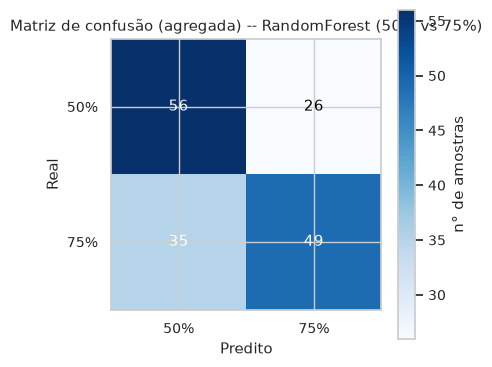

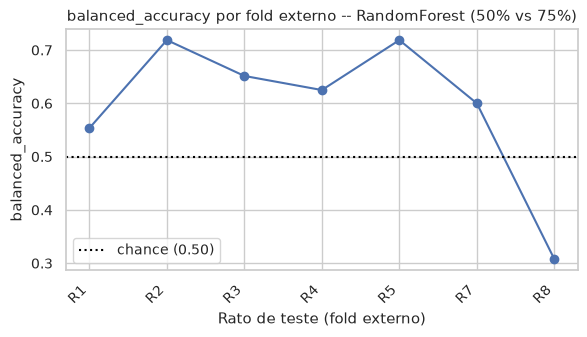


######################################################################
# RandomForest (50% vs 75%) -- modelo final (todos os ratos) p/ interpretação (SHAP)
######################################################################
    [RandomForest (50% vs 75%) [modelo final]] testando passo_pct=20...
      -> sem seleção: score=0.636
      -> com seleção: score=0.651
    [RandomForest (50% vs 75%) [modelo final]] config interna escolhida: passo_pct=20 | seleção=com | CV interna=0.651 | params={'clf__class_weight': 'balanced', 'clf__max_depth': 3, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 100, 'selector__max_features': 15}


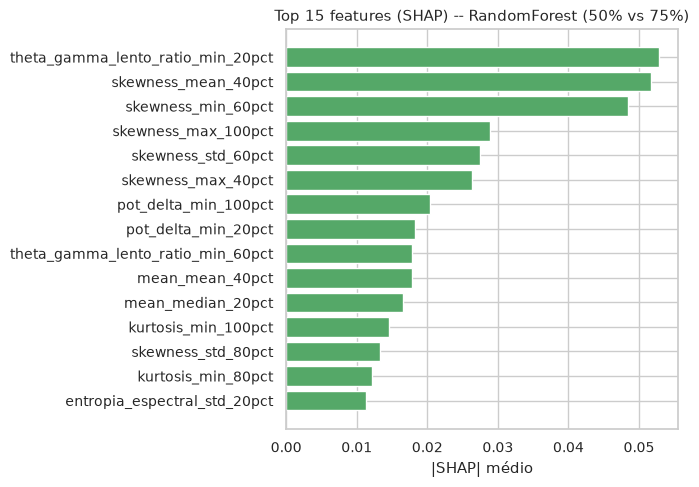

In [7]:
# Grade mais ampla (a pedido explícito, aceitando rodar mais devagar):
# +1 valor de n_estimators, +1 de max_depth, +1 de min_samples_leaf, entrou
# min_samples_split, max_features ganhou mais frações contínuas, e
# class_weight agora testa também "balanced_subsample" (reamostra o balanço
# de classe em cada árvore do bagging, não só uma vez -- pode ajudar com
# poucos ratos). Combos por passo_pct (sem contar seleção de atributos):
# 4*5*4*3*4*2 = 1920 (SEMSEL) -- e mais TOP_N_FEATURES_GRID (5) de multiplicador
# no COMSEL. Isso é MUITO mais caro que a grade anterior (ordem de ~10-15x);
# se travar na sua máquina, o primeiro corte recomendado é remover
# min_samples_split ou reduzir max_features para 3 valores.
PARAM_GRID_RF_SEMSEL = {
    "clf__n_estimators": [100, 200, 300],          # 3
    "clf__max_depth": [3, 8, 12],            # 4
    "clf__min_samples_leaf": [1, 2, 3],         # 4
    "clf__min_samples_split": [2, 10],          # 3
    "clf__max_features": ["sqrt", 0.3, 0.6],       # 3
    "clf__class_weight": ["balanced", "balanced_subsample"],  # 2
}
PARAM_GRID_RF_COMSEL = {
    "selector__max_features": TOP_N_FEATURES_GRID,
    **PARAM_GRID_RF_SEMSEL,
}

rf_base = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)

saida_rf = pipeline_binario_aninhado(
    df_limpo, nome_modelo="RandomForest (50% vs 75%)", estimator=rf_base,
    param_grid_semsel=PARAM_GRID_RF_SEMSEL, param_grid_comsel=PARAM_GRID_RF_COMSEL,
)


## 6. Regressão Logística — Pipeline Completo (CV aninhada)

Grade reduzida em relação ao original: com CV aninhada o custo é multiplicado
pelo número de ratos no loop externo, então fixei `solver`, `class_weight` e
`fit_intercept` nos valores que já haviam se mostrado bons no notebook original,
e deixei `C` como principal hiperparâmetro de busca. Amplie se tiver tempo.


######################################################################
# Regressão Logística (50% vs 75%) -- CV ANINHADA (nested Leave-One-Rat-Out)
######################################################################

[Regressão Logística (50% vs 75%)] Fold externo 1/7 -- rato de teste: R1
    [Regressão Logística (50% vs 75%)] testando passo_pct=20...
      -> sem seleção: score=0.725
      -> com seleção: score=0.690
    [Regressão Logística (50% vs 75%)] config interna escolhida: passo_pct=20 | seleção=sem | CV interna=0.725 | params={'clf__C': 0.3, 'clf__class_weight': None, 'clf__l1_ratio': 0.75, 'clf__max_iter': 5000, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
  [Regressão Logística (50% vs 75%)] fold 1/7 -- teste=rato R1 (n=18) | passo_pct=20 | bal_acc=0.321 | f1_macro=0.222

[Regressão Logística (50% vs 75%)] Fold externo 2/7 -- rato de teste: R2
    [Regressão Logística (50% vs 75%)] testando passo_pct=20...
      -> sem seleção: score=0.592
      -> com seleção: 

,rato_teste,passo_pct,usa_selecao,params
0,R1,20,False,"{'clf__C': 0.3, 'clf__class_weight': None, 'cl..."
1,R2,20,True,"{'clf__C': 1, 'clf__class_weight': 'balanced',..."
2,R3,20,False,"{'clf__C': 0.3, 'clf__class_weight': None, 'cl..."
3,R4,20,True,"{'clf__C': 100, 'clf__class_weight': None, 'cl..."
4,R5,20,False,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
5,R7,20,True,"{'clf__C': 0.3, 'clf__class_weight': 'balanced..."
6,R8,20,True,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."


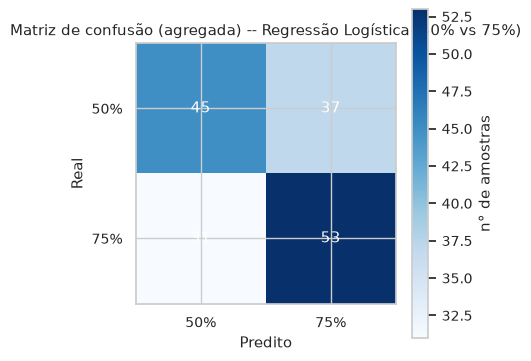

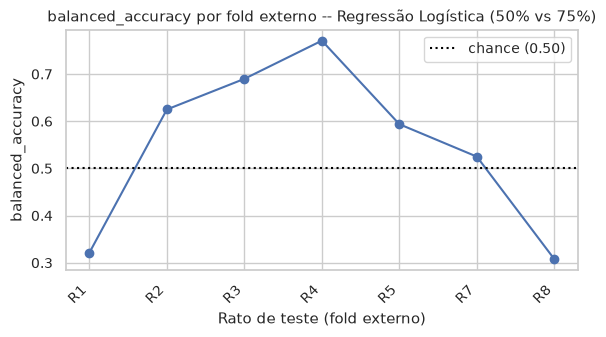


######################################################################
# Regressão Logística (50% vs 75%) -- modelo final (todos os ratos) p/ interpretação (SHAP)
######################################################################
    [Regressão Logística (50% vs 75%) [modelo final]] testando passo_pct=20...
      -> sem seleção: score=0.606
      -> com seleção: score=0.618
    [Regressão Logística (50% vs 75%) [modelo final]] config interna escolhida: passo_pct=20 | seleção=com | CV interna=0.618 | params={'clf__C': 100, 'clf__class_weight': None, 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'selector__max_features': 10}


Background dataset has 166 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=166 when initializing the masker.


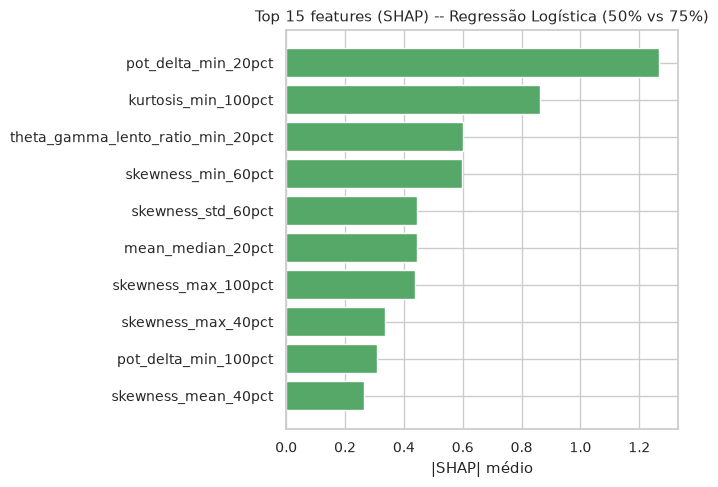

In [8]:
# Grid reduzido: mantém apenas valores que apareceram como melhores
# em pelo menos um fold da CV aninhada ou no modelo final.

_LOGREG_C_GRID = [
    0.1,
    0.3,
    1,
    100,
]

_LOGREG_CLASS_WEIGHT_GRID = [
    None,
    "balanced",
]

_LOGREG_L1_RATIO_GRID = [
    0.25,
    0.50,
    0.65,
    0.75,
]

PARAM_GRID_LOGREG_SEMSEL = [
    {
        "clf__penalty": ["l2"],
        "clf__solver": ["saga"],
        "clf__C": _LOGREG_C_GRID,
        "clf__class_weight": _LOGREG_CLASS_WEIGHT_GRID,
        "clf__max_iter": [5000],
    },
    {
        "clf__penalty": ["elasticnet"],
        "clf__solver": ["saga"],
        "clf__C": _LOGREG_C_GRID,
        "clf__l1_ratio": _LOGREG_L1_RATIO_GRID,
        "clf__class_weight": _LOGREG_CLASS_WEIGHT_GRID,
        "clf__max_iter": [5000],
    },
]

# COMSEL: mesma lista, acrescentando selector__max_features.
PARAM_GRID_LOGREG_COMSEL = [
    {**bloco, "selector__max_features": TOP_N_FEATURES_GRID}
    for bloco in PARAM_GRID_LOGREG_SEMSEL
]

logreg_base = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

saida_logreg = pipeline_binario_aninhado(
    df_limpo,
    nome_modelo="Regressão Logística (50% vs 75%)",
    estimator=logreg_base,
    param_grid_semsel=PARAM_GRID_LOGREG_SEMSEL,
    param_grid_comsel=PARAM_GRID_LOGREG_COMSEL,
)

## 7. XGBoost — Pipeline Completo (CV aninhada)

Agora binário (`objective="binary:logistic"`), então os rótulos `50/75` são
recodificados para `0/1` via `y_transformer`, e os relatórios finais são
traduzidos de volta via `inverse_label_fn` (mesma lógica do notebook original).


######################################################################
# XGBoost (50% vs 75%) -- CV ANINHADA (nested Leave-One-Rat-Out)
######################################################################

[XGBoost (50% vs 75%)] Fold externo 1/7 -- rato de teste: R1
    [XGBoost (50% vs 75%)] testando passo_pct=20...
      -> sem seleção: score=0.640
      -> com seleção: score=0.647
    [XGBoost (50% vs 75%)] config interna escolhida: passo_pct=20 | seleção=com | CV interna=0.647 | params={'clf__colsample_bytree': 1.0, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__reg_lambda': 10, 'clf__subsample': 1.0, 'selector__max_features': 20}
  [XGBoost (50% vs 75%)] fold 1/7 -- teste=rato R1 (n=18) | passo_pct=20 | bal_acc=0.679 | f1_macro=0.498

[XGBoost (50% vs 75%)] Fold externo 2/7 -- rato de teste: R2
    [XGBoost (50% vs 75%)] testando passo_pct=20...
      -> sem seleção: score=0.540
      -> com seleção: 

,rato_teste,passo_pct,usa_selecao,params
0,R1,20,True,"{'clf__colsample_bytree': 1.0, 'clf__gamma': 0..."
1,R2,20,True,"{'clf__colsample_bytree': 1.0, 'clf__gamma': 0..."
2,R3,20,True,"{'clf__colsample_bytree': 0.7, 'clf__gamma': 0..."
3,R4,20,True,"{'clf__colsample_bytree': 1.0, 'clf__gamma': 0..."
4,R5,20,True,"{'clf__colsample_bytree': 1.0, 'clf__gamma': 0..."
5,R7,20,True,"{'clf__colsample_bytree': 0.7, 'clf__gamma': 0..."
6,R8,20,True,"{'clf__colsample_bytree': 0.7, 'clf__gamma': 0..."


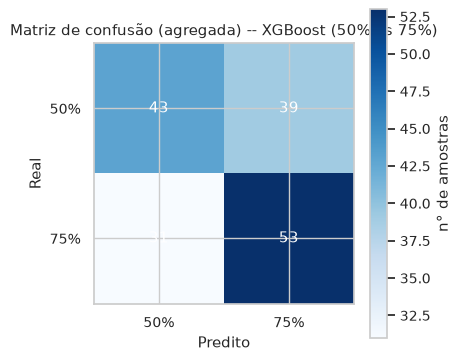

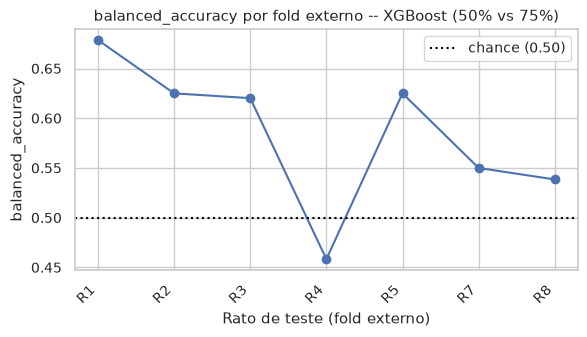


######################################################################
# XGBoost (50% vs 75%) -- modelo final (todos os ratos) p/ interpretação (SHAP)
######################################################################
    [XGBoost (50% vs 75%) [modelo final]] testando passo_pct=20...
      -> sem seleção: score=0.624
      -> com seleção: score=0.643
    [XGBoost (50% vs 75%) [modelo final]] config interna escolhida: passo_pct=20 | seleção=com | CV interna=0.643 | params={'clf__colsample_bytree': 0.7, 'clf__gamma': 0.5, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 10, 'clf__subsample': 0.7, 'selector__max_features': 20}


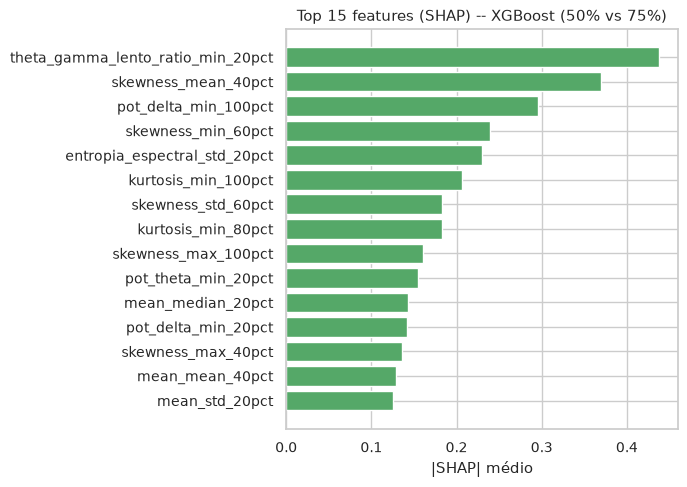

In [9]:
if XGBOOST_DISPONIVEL:
    MAPA_XGB = {c: i for i, c in enumerate(CONDICOES_ALVO)}   # {50: 0, 75: 1}
    MAPA_XGB_INV = {i: c for c, i in MAPA_XGB.items()}

    def codificar_y_xgb(y_series):
        return y_series.map(MAPA_XGB)

    def decodificar_y_xgb(labels_codificados):
        return [MAPA_XGB_INV[l] for l in labels_codificados]

    # Grade mais ampla (a pedido explícito): +1 valor de max_depth e
    # learning_rate, subsample/colsample ganharam um ponto intermediário, e
    # entraram reg_lambda (regularização L2 nas folhas) e gamma (ganho mínimo
    # pra abrir um novo split) -- ambos ajudam a controlar overfitting, que é
    # o maior risco aqui dado que cada fold de treino tem só 6 ratos.
    # Combos por passo_pct (SEMSEL): 3*4*4*3*3*2*3*3 = 15552 -- bem mais caro
    # que a grade anterior (~108). Se travar: os primeiros cortes recomendados
    # são tirar "gamma" e reduzir "min_child_weight" pra um valor só.
    PARAM_GRID_XGB_SEMSEL = {
        "clf__n_estimators": [100, 200],          # 3
        "clf__max_depth": [2, 4],                   # 3
        "clf__learning_rate": [0.05, 0.1],             # 2
        "clf__subsample": [0.7, 1.0],                  # 2
        "clf__colsample_bytree": [0.7, 1.0],           # 2
        "clf__min_child_weight": [1, 3],               # 2
        "clf__reg_lambda": [1, 10],                    # 2
        "clf__gamma": [0, 0.5],                        # 2
    }
    PARAM_GRID_XGB_COMSEL = {
        "selector__max_features": TOP_N_FEATURES_GRID,
        **PARAM_GRID_XGB_SEMSEL,
    }

    xgb_base = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
    )

    saida_xgb = pipeline_binario_aninhado(
        df_limpo, nome_modelo="XGBoost (50% vs 75%)", estimator=xgb_base,
        param_grid_semsel=PARAM_GRID_XGB_SEMSEL, param_grid_comsel=PARAM_GRID_XGB_COMSEL,
        y_transformer=codificar_y_xgb, inverse_label_fn=decodificar_y_xgb,
    )
else:
    saida_xgb = None
    print("Pulando seção XGBoost -- pacote 'xgboost' não disponível (pip install xgboost).")


## 8. Teste de Permutação (config fixa por fold, simplificação documentada)

Refazer a CV interna para cada uma das permutações multiplicaria o custo já alto
da CV aninhada por `n_permutacoes` -- inviável no prazo. Aqui, para cada fold
externo, reaproveitamos a **mesma configuração** (`passo_pct`, seleção, hiperparâmetros)
já escolhida com os dados reais, e só re-treinamos/reavaliamos com os rótulos
embaralhados **por arquivo** (`stem`) -- preservando a estrutura de que todas as
áreas de um mesmo arquivo têm a mesma condição.

**Limitação a admitir se perguntarem:** a distribuição nula aqui não captura a
variância de "escolher a configuração vencedora", então o p-valor é uma
aproximação prática, não o valor exato de um teste de permutação totalmente
aninhado. Rodamos só para o modelo com maior acurácia observada (mesmo espírito
do notebook original, que testava só o RF).

Modelo com maior balanced_accuracy observada: RandomForest (50% vs 75%)
Modelos mapeados disponíveis: ['RandomForest (50% vs 75%)', 'Regressão Logística (50% vs 75%)', 'XGBoost (50% vs 75%)']
Estimator selecionado: RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42)
[RandomForest (50% vs 75%)] iniciando teste de permutação: 50 permutações x 7 folds (ratos)
[RandomForest (50% vs 75%)] balanced_accuracy observado (referência): 0.596
    [RandomForest (50% vs 75%)] perm 1/50 | fold 1/7 (rato=R1) -> bal_acc=0.362
    [RandomForest (50% vs 75%)] perm 1/50 | fold 2/7 (rato=R2) -> bal_acc=0.469
    [RandomForest (50% vs 75%)] perm 1/50 | fold 3/7 (rato=R3) -> bal_acc=0.450
    [RandomForest (50% vs 75%)] perm 1/50 | fold 4/7 (rato=R4) -> bal_acc=0.604
    [RandomForest (50% vs 75%)] perm 1/50 | fold 5/7 (rato=R5) -> bal_acc=0.562
    [RandomForest (50% vs 75%)] perm 1/50 | fold 6/7 (rato=R7) -> bal_acc=0.650
    [RandomForest (50% vs 75%)] perm 1/50 | fold 7/7 (rato=R8)

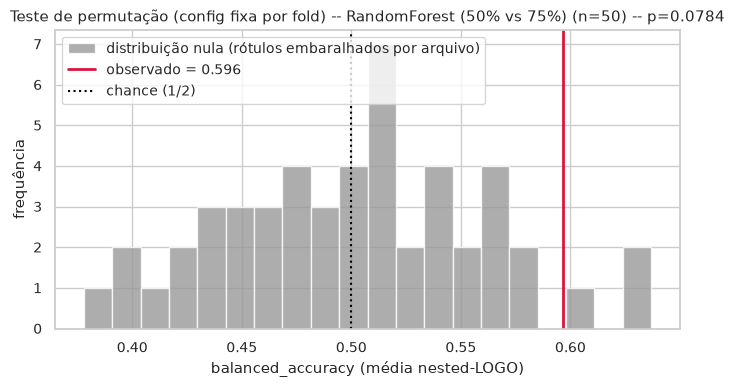

In [18]:
import time

def teste_permutacao_aninhado_simplificado(df_long_limpo, resultado_aninhado, estimator,
                                            y_transformer=None, n_permutacoes=50,
                                            random_state=RANDOM_STATE, rotulo="modelo"):
    rng = np.random.RandomState(random_state)
    y_transformer = y_transformer or (lambda y: y)
    df_configs = resultado_aninhado["df_configs_por_fold"].set_index("rato_teste")
    bal_acc_observado = resultado_aninhado["df_resultados"]["balanced_accuracy"].mean()
    ratos = resultado_aninhado["df_resultados"]["rato_teste"].tolist()

    print(f"[{rotulo}] iniciando teste de permutação: {n_permutacoes} permutações x {len(ratos)} folds (ratos)")
    print(f"[{rotulo}] balanced_accuracy observado (referência): {bal_acc_observado:.3f}")

    t0_total = time.time()
    bal_acc_nulo = []
    for p in range(n_permutacoes):
        t0_perm = time.time()

        # embaralha 'condicao' por ARQUIVO (stem), preservando a estrutura de que
        # todas as áreas do mesmo arquivo compartilham a mesma condição
        mapa_stem = df_long_limpo.drop_duplicates("stem")[["stem", "condicao"]].copy()
        mapa_stem["condicao_perm"] = rng.permutation(mapa_stem["condicao"].values)
        df_perm = df_long_limpo.merge(mapa_stem[["stem", "condicao_perm"]], on="stem", how="left")
        df_perm = df_perm.drop(columns=["condicao"]).rename(columns={"condicao_perm": "condicao"})

        bal_accs_fold = []
        for i, rato_teste in enumerate(ratos, start=1):
            cfg = df_configs.loc[rato_teste]
            df_treino_long = df_perm[df_perm["rato"] != rato_teste]
            df_teste_long = df_perm[df_perm["rato"] == rato_teste]
            X_tr, y_tr, _, X_te, y_te, _, _ = montar_dataset_treino_teste(
                df_treino_long, df_teste_long, cfg["passo_pct"]
            )
            y_tr = y_transformer((y_tr * 100).round().astype(int))
            y_te = y_transformer((y_te * 100).round().astype(int))
            pipe = montar_pipeline_binaria(clone(estimator), cfg["usa_selecao"])
            pipe.set_params(**cfg["params"])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                acc_fold = balanced_accuracy_score(y_te, y_pred)
            bal_accs_fold.append(acc_fold)
            print(f"    [{rotulo}] perm {p+1}/{n_permutacoes} | fold {i}/{len(ratos)} (rato={rato_teste}) -> bal_acc={acc_fold:.3f}")

        media_perm = np.mean(bal_accs_fold)
        bal_acc_nulo.append(media_perm)
        dt_perm = time.time() - t0_perm
        print(f"  [{rotulo}] permutação {p+1}/{n_permutacoes} concluída -> média={media_perm:.3f} ({dt_perm:.1f}s)")

    dt_total = time.time() - t0_total
    print(f"[{rotulo}] todas as {n_permutacoes} permutações concluídas em {dt_total:.1f}s "
          f"({dt_total/n_permutacoes:.1f}s/permutação em média)")

    bal_acc_nulo = np.array(bal_acc_nulo)
    p_valor = (np.sum(bal_acc_nulo >= bal_acc_observado) + 1) / (n_permutacoes + 1)

    print(f"\n[{rotulo}] balanced_accuracy observado: {bal_acc_observado:.3f}")
    print(f"[{rotulo}] balanced_accuracy nulo (média ± dp): {bal_acc_nulo.mean():.3f} ± {bal_acc_nulo.std():.3f}")
    print(f"[{rotulo}] p-valor (permutação, n={n_permutacoes}, config fixa por fold): {p_valor:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(bal_acc_nulo, bins=20, color="#999999", alpha=0.8, label="distribuição nula (rótulos embaralhados por arquivo)")
    ax.axvline(bal_acc_observado, color="crimson", linewidth=2, label=f"observado = {bal_acc_observado:.3f}")
    ax.axvline(0.5, color="black", linestyle=":", label="chance (1/2)")
    ax.set_xlabel("balanced_accuracy (média nested-LOGO)")
    ax.set_ylabel("frequência")
    ax.set_title(f"Teste de permutação (config fixa por fold) -- {rotulo} (n={n_permutacoes}) -- p={p_valor:.4f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {"bal_acc_observado": bal_acc_observado, "bal_acc_nulo": bal_acc_nulo, "p_valor": p_valor}


saidas_disponiveis = [s for s in [saida_rf, saida_logreg, saida_xgb] if s is not None]
melhor_saida = max(
    saidas_disponiveis,
    key=lambda s: s["resultado"]["df_resultados"]["balanced_accuracy"].mean(),
)
print(f"Modelo com maior balanced_accuracy observada: {melhor_saida['nome_modelo']}")

# mapeia nome_modelo -> (estimator_base, y_transformer), cobrindo os três modelos possíveis
modelos_base = {}
if saida_rf is not None:
    modelos_base[saida_rf["nome_modelo"]] = (rf_base, lambda y: y)
if saida_logreg is not None:
    modelos_base[saida_logreg["nome_modelo"]] = (logreg_base, lambda y: y)
if saida_xgb is not None and XGBOOST_DISPONIVEL:
    modelos_base[saida_xgb["nome_modelo"]] = (xgb_base, codificar_y_xgb)

print(f"Modelos mapeados disponíveis: {list(modelos_base.keys())}")

estimator_melhor, y_transformer_melhor = modelos_base[melhor_saida["nome_modelo"]]
print(f"Estimator selecionado: {estimator_melhor}")

# Ajuste n_permutacoes conforme o tempo disponível (50 já dá uma ideia; 100-200
# dá um p-valor mais preciso se sobrar tempo).
resultado_permutacao = teste_permutacao_aninhado_simplificado(
    df_limpo, melhor_saida["resultado"], clone(estimator_melhor),
    y_transformer=y_transformer_melhor, n_permutacoes=50, rotulo=melhor_saida["nome_modelo"],
)

## 9. Comparação Final e Exportação dos Resultados

Esta seção existia só no sumário do notebook original -- o código nunca tinha
sido escrito (e a variável `pasta_multiclasse`, usada aqui, nunca havia sido
definida). Ambos os problemas estão corrigidos aqui.


=== Comparação final -- LogReg vs XGBoost (50% vs 75%, CV aninhada) ===


,modelo,balanced_accuracy_media,balanced_accuracy_dp,f1_macro_media,precision_macro_media,recall_macro_media,n_folds
0,RandomForest (50% vs 75%),0.596,0.141,0.563,0.650,0.574,7
2,XGBoost (50% vs 75%),0.585,0.074,0.521,0.578,0.547,7
1,Regressão Logística (50% vs 75%),0.548,0.177,0.522,0.580,0.526,7


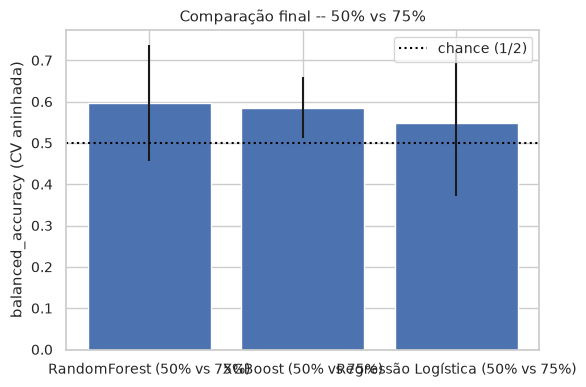


Resultados salvos em: /home/joyceribeiro/projetos/TCC_joyce_xavier/lemcog_clean/ML_Export/resultados_tentativa


In [19]:
linhas_comparacao = []
for saida in saidas_disponiveis:
    df_r = saida["resultado"]["df_resultados"]
    linhas_comparacao.append({
        "modelo": saida["nome_modelo"],
        "balanced_accuracy_media": df_r["balanced_accuracy"].mean(),
        "balanced_accuracy_dp": df_r["balanced_accuracy"].std(),
        "f1_macro_media": df_r["f1_macro"].mean(),
        "precision_macro_media": df_r["precision_macro"].mean(),
        "recall_macro_media": df_r["recall_macro"].mean(),
        "n_folds": len(df_r),
    })

df_comparacao = pd.DataFrame(linhas_comparacao).sort_values("balanced_accuracy_media", ascending=False)
print("\n=== Comparação final -- LogReg vs XGBoost (50% vs 75%, CV aninhada) ===")
display(df_comparacao.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_comparacao["modelo"], df_comparacao["balanced_accuracy_media"],
       yerr=df_comparacao["balanced_accuracy_dp"], color="#4C72B0")
ax.axhline(0.5, color="black", linestyle=":", label="chance (1/2)")
ax.set_ylabel("balanced_accuracy (CV aninhada)")
ax.set_title("Comparação final -- 50% vs 75%")
ax.legend()
plt.tight_layout()
plt.show()

df_comparacao.to_csv(pasta_multiclasse / "comparacao_final_logreg_xgb_50_75.csv", index=False)

for saida in saidas_disponiveis:
    nome_arquivo = (
        saida["nome_modelo"].lower()
        .replace(" ", "_").replace("(", "").replace(")", "").replace("%", "pct")
    )
    saida["resultado"]["df_resultados"].to_csv(
        pasta_multiclasse / f"resultados_por_fold_{nome_arquivo}.csv", index=False
    )
    saida["resultado"]["df_configs_por_fold"].to_csv(
        pasta_multiclasse / f"configs_por_fold_{nome_arquivo}.csv", index=False
    )

print(f"\nResultados salvos em: {pasta_multiclasse.resolve()}")


## 10. Checklist de Análise dos Modelos

Tudo que vem a partir daqui **não** re-treina nada -- só analisa o que já foi
calculado nas Seções 5-9 (`saidas_disponiveis`, cada item com `resultado`
contendo `df_resultados`, `df_predicoes_detalhadas`, `df_importancias_por_fold`,
`matriz_confusao`).

`df_predicoes_detalhadas` e `df_importancias_por_fold` só existem se você rodou
o notebook **depois** da atualização da Seção 4 (as funções foram alteradas
para registrar, por amostra de teste: `fold`, `rato_teste`, `area`, `y_true`,
`y_pred`, `y_score` -- e, por fold externo, a importância/coeficiente de cada
feature usada pelo classificador). Se você já tinha resultados de uma versão
anterior do notebook, **rode a Seção 5-9 de novo** antes de usar esta parte.

Estrutura desta parte (segue o checklist que você me passou):

1. Desempenho geral (acurácia, precisão, recall, F1, AUC)
2. Matriz de confusão
3. Análise dos erros
4. Análise dos acertos
5. Análise por rato
6. Análise por feature / região cerebral
7. Cruzamento rato × região
8. Comparação entre modelos
9. Comparação com a literatura
10. Resumo executivo (respostas às perguntas-guia)

### 10.1 Desempenho geral

Acurácia, precisão, recall, F1 e AUC de cada modelo -- calculados de duas
formas complementares:

- **Nível fold** (`df_resultados`): a média/desvio-padrão das métricas
  *macro* já calculadas por rato de teste (é o que a CV aninhada reporta
  oficialmente -- cada rato pesa igual, independente de quantas amostras
  tenha).
- **Nível amostra** (`df_predicoes_detalhadas`, todas as amostras de teste de
  todos os folds empilhadas): dá a métrica "global", que pode diferir um
  pouco da média por fold se os ratos tiverem números de amostras muito
  diferentes.

=== 10.1 Desempenho geral (todos os modelos) ===


,modelo,balanced_accuracy_fold_media,balanced_accuracy_fold_dp,f1_macro_fold_media,precision_macro_fold_media,recall_macro_fold_media,acuracia_global_amostra,n_amostras_teste_total,auc_global
0,RandomForest (50% vs 75%),0.596,0.141,0.563,0.650,0.574,0.633,166,0.657
2,XGBoost (50% vs 75%),0.585,0.074,0.521,0.578,0.547,0.578,166,0.630
1,Regressão Logística (50% vs 75%),0.548,0.177,0.522,0.580,0.526,0.590,166,0.664


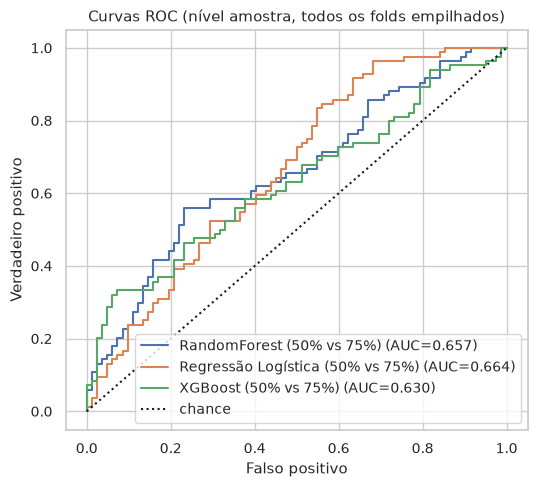

In [20]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
)

linhas_desempenho = []
curvas_roc = {}

for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    resultado = saida["resultado"]
    df_r = resultado["df_resultados"]
    df_pred = resultado.get("df_predicoes_detalhadas", pd.DataFrame())

    linha = {
        "modelo": nome,
        # -- nível fold (CV aninhada oficial) --
        "balanced_accuracy_fold_media": df_r["balanced_accuracy"].mean(),
        "balanced_accuracy_fold_dp": df_r["balanced_accuracy"].std(),
        "f1_macro_fold_media": df_r["f1_macro"].mean(),
        "precision_macro_fold_media": df_r["precision_macro"].mean(),
        "recall_macro_fold_media": df_r["recall_macro"].mean(),
    }

    if not df_pred.empty:
        y_true = df_pred["y_true"]
        y_pred = df_pred["y_pred"]
        linha["acuracia_global_amostra"] = accuracy_score(y_true, y_pred)
        linha["n_amostras_teste_total"] = len(df_pred)

        if df_pred["y_score"].notna().all():
            classe_positiva = max(resultado["labels_multi"])
            try:
                auc = roc_auc_score((y_true == classe_positiva).astype(int), df_pred["y_score"])
                linha["auc_global"] = auc
                fpr, tpr, _ = roc_curve((y_true == classe_positiva).astype(int), df_pred["y_score"])
                curvas_roc[nome] = (fpr, tpr, auc)
            except ValueError:
                linha["auc_global"] = np.nan
        else:
            linha["auc_global"] = np.nan  # modelo sem predict_proba (ou y_score não capturado)

    linhas_desempenho.append(linha)

df_desempenho_geral = pd.DataFrame(linhas_desempenho).sort_values(
    "balanced_accuracy_fold_media", ascending=False
)
print("=== 10.1 Desempenho geral (todos os modelos) ===")
display(df_desempenho_geral.round(3))
df_desempenho_geral.to_csv(pasta_multiclasse / "10_1_desempenho_geral.csv", index=False)

if curvas_roc:
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for nome, (fpr, tpr, auc) in curvas_roc.items():
        ax.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k:", label="chance")
    ax.set_xlabel("Falso positivo")
    ax.set_ylabel("Verdadeiro positivo")
    ax.set_title("Curvas ROC (nível amostra, todos os folds empilhados)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma curva ROC disponível (nenhum modelo com y_score capturado).")

### 10.2 Matriz de confusão

Reaproveita `matriz_confusao` (já plotada na Seção 5-7), mas agora também
extrai em tabela: acerto por classe (diagonal / soma da linha) e qual par de
classes concentra mais confusão -- como o problema é binário (50% vs 75%),
"classe mais confundida" aqui é simplesmente qual das duas é mais errada.

In [21]:
linhas_matriz = []
for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    resultado = saida["resultado"]
    cm = resultado["matriz_confusao"]
    labels_plot = resultado["labels"]

    for i_classe, rotulo_classe in enumerate(labels_plot):
        n_total_classe = cm[i_classe].sum()
        n_acertos_classe = cm[i_classe, i_classe]
        linhas_matriz.append({
            "modelo": nome,
            "classe_real": rotulo_classe,
            "n_amostras": n_total_classe,
            "n_acertos": n_acertos_classe,
            "n_erros": n_total_classe - n_acertos_classe,
            "taxa_acerto_classe": n_acertos_classe / n_total_classe if n_total_classe else np.nan,
        })

df_matriz_por_classe = pd.DataFrame(linhas_matriz)
print("=== 10.2 Acerto por classe, extraído da matriz de confusão ===")
display(df_matriz_por_classe.round(3))

print("\nClasse com pior taxa de acerto, por modelo:")
display(
    df_matriz_por_classe.loc[df_matriz_por_classe.groupby("modelo")["taxa_acerto_classe"].idxmin()]
    .reset_index(drop=True)
)
df_matriz_por_classe.to_csv(pasta_multiclasse / "10_2_matriz_confusao_por_classe.csv", index=False)

=== 10.2 Acerto por classe, extraído da matriz de confusão ===


,modelo,classe_real,n_amostras,n_acertos,n_erros,taxa_acerto_classe
0,RandomForest (50% vs 75%),50%,82,56,26,0.683
1,RandomForest (50% vs 75%),75%,84,49,35,0.583
2,Regressão Logística (50% vs 75%),50%,82,45,37,0.549
3,Regressão Logística (50% vs 75%),75%,84,53,31,0.631
4,XGBoost (50% vs 75%),50%,82,43,39,0.524
5,XGBoost (50% vs 75%),75%,84,53,31,0.631



Classe com pior taxa de acerto, por modelo:


,modelo,classe_real,n_amostras,n_acertos,n_erros,taxa_acerto_classe
0,RandomForest (50% vs 75%),75%,84,49,35,0.583333
1,Regressão Logística (50% vs 75%),50%,82,45,37,0.548780
2,XGBoost (50% vs 75%),50%,82,43,39,0.524390


### 10.3 Análise dos erros

Usa `df_predicoes_detalhadas` (uma linha por amostra de teste, todos os
folds/ratos empilhados) para responder: quais classes erram mais, se há
padrão nos erros (concentrados em poucos ratos? em poucas áreas?), quais
erros se repetem entre modelos, e exemplos concretos de classificações
incorretas.

In [22]:
dfs_erros = {}
for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    df_pred = saida["resultado"].get("df_predicoes_detalhadas", pd.DataFrame())
    if df_pred.empty:
        continue
    erros = df_pred[~df_pred["acerto"]].copy()
    dfs_erros[nome] = erros

    print(f"\n{'='*70}\n[{nome}] -- {len(erros)}/{len(df_pred)} amostras erradas "
          f"({len(erros)/len(df_pred):.1%})\n{'='*70}")

    print("\nErros por classe real (qual condição o modelo mais erra ao classificar):")
    display(erros["y_true"].value_counts().rename("n_erros").to_frame())

    print("\nErros por área/região cerebral:")
    display(
        erros.groupby("area").size().sort_values(ascending=False).rename("n_erros").to_frame()
    )

    print("\nErros por rato de teste:")
    display(
        erros.groupby("rato_teste").size().sort_values(ascending=False).rename("n_erros").to_frame()
    )

    print("\nExemplos de classificações incorretas (10 primeiras):")
    display(erros[["fold", "rato_teste", "area", "y_true", "y_pred", "y_score"]].head(10))

# Erros que se repetem em MAIS DE UM modelo (mesmo rato + mesma área + mesma classe real)
if len(dfs_erros) > 1:
    chave = ["rato_teste", "area", "y_true"]
    contagem_modelos_por_erro = None
    for nome, erros in dfs_erros.items():
        marca = erros[chave].drop_duplicates().assign(**{f"errou_{nome}": True})
        contagem_modelos_por_erro = (
            marca if contagem_modelos_por_erro is None
            else contagem_modelos_por_erro.merge(marca, on=chave, how="outer")
        )
    colunas_erro = [c for c in contagem_modelos_por_erro.columns if c.startswith("errou_")]
    contagem_modelos_por_erro[colunas_erro] = contagem_modelos_por_erro[colunas_erro].fillna(False)
    contagem_modelos_por_erro["n_modelos_que_erraram"] = contagem_modelos_por_erro[colunas_erro].sum(axis=1)
    contagem_modelos_por_erro = contagem_modelos_por_erro.sort_values(
        "n_modelos_que_erraram", ascending=False
    )
    print("\n=== Combinações (rato, área, classe real) erradas por mais de um modelo ===")
    display(contagem_modelos_por_erro[contagem_modelos_por_erro["n_modelos_que_erraram"] > 1].head(20))
    contagem_modelos_por_erro.to_csv(pasta_multiclasse / "10_3_erros_compartilhados_entre_modelos.csv", index=False)


[RandomForest (50% vs 75%)] -- 61/166 amostras erradas (36.7%)

Erros por classe real (qual condição o modelo mais erra ao classificar):


,n_erros
y_true,
75,35
50,26



Erros por área/região cerebral:


,n_erros
area,
DGV,18
CA3c,16
DGD,16
CA3b,11



Erros por rato de teste:


...

,n_erros
rato_teste,
R4,14
R5,12
R2,12
R3,11
R1,9
R7,6
R8,6



Exemplos de classificações incorretas (10 primeiras):


,fold,rato_teste,area,y_true,y_pred,y_score
2,1,R1,DGV,0,1,0.682098
3,1,R1,CA3b,0,1,0.922319
4,1,R1,CA3c,0,1,0.797636
6,1,R1,DGV,0,1,0.902495
9,1,R1,DGV,0,1,0.573014
10,1,R1,CA3b,0,1,0.854510
11,1,R1,CA3c,0,1,0.896669
12,1,R1,DGD,0,1,0.895352
13,1,R1,DGV,0,1,0.791773
18,2,R2,CA3b,0,1,0.943067



=== Combinações (rato, área, classe real) erradas por mais de um modelo ===


,rato_teste,area,y_true,errou_RandomForest (50% vs 75%),errou_Regressão Logística (50% vs 75%),errou_XGBoost (50% vs 75%),n_modelos_que_erraram
72,R8,DGV,75,True,True,False,2
63,R7,DGD,75,True,True,False,2
1,R1,CA3b,50,True,True,False,2
34,R4,CA3b,75,True,True,False,2
50,R5,CA3c,50,True,True,False,2
31,R3,DGV,75,True,True,False,2
54,R5,DGD,75,True,True,False,2
56,R5,DGV,50,True,True,False,2
24,R3,CA3c,75,True,True,False,2
58,R7,CA3b,50,True,True,False,2


### 10.4 Análise dos acertos

Espelha a análise de erros: quais classes são acertadas com mais frequência,
se há padrão (concentração em certas áreas/ratos) e comparação entre
modelos.

In [23]:
dfs_acertos = {}
for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    df_pred = saida["resultado"].get("df_predicoes_detalhadas", pd.DataFrame())
    if df_pred.empty:
        continue
    acertos = df_pred[df_pred["acerto"]].copy()
    dfs_acertos[nome] = acertos

    print(f"\n[{nome}] -- {len(acertos)}/{len(df_pred)} amostras corretas ({len(acertos)/len(df_pred):.1%})")
    print("Acertos por classe real:")
    display(acertos["y_true"].value_counts().rename("n_acertos").to_frame())
    print("Acertos por área/região cerebral (top 10):")
    display(
        acertos.groupby("area").size().sort_values(ascending=False).rename("n_acertos").to_frame().head(10)
    )

# Comparação de taxa de acerto por classe entre modelos, lado a lado
if dfs_acertos:
    comparacao_acertos = pd.DataFrame({
        nome: saidas_disponiveis[i]["resultado"]["df_predicoes_detalhadas"]
              .groupby("y_true")["acerto"].mean()
        for i, nome in enumerate(dfs_acertos.keys())
    })
    print("\n=== Taxa de acerto por classe real, lado a lado entre modelos ===")
    display(comparacao_acertos.round(3))
    comparacao_acertos.to_csv(pasta_multiclasse / "10_4_taxa_acerto_por_classe_entre_modelos.csv")


[RandomForest (50% vs 75%)] -- 105/166 amostras corretas (63.3%)
Acertos por classe real:


,n_acertos
y_true,
50,56
75,49


Acertos por área/região cerebral (top 10):


,n_acertos
area,
CA3b,29
DGD,27
CA3c,25
DGV,24



[Regressão Logística (50% vs 75%)] -- 98/166 amostras corretas (59.0%)
Acertos por classe real:


...

,n_acertos
y_true,
1,53
0,43


Acertos por área/região cerebral (top 10):


,n_acertos
area,
DGD,28
CA3b,25
CA3c,23
DGV,20



=== Taxa de acerto por classe real, lado a lado entre modelos ===


,RandomForest (50% vs 75%),Regressão Logística (50% vs 75%),XGBoost (50% vs 75%)
y_true,,,
0,NaN,NaN,0.524
1,NaN,NaN,0.631
50,0.683,0.549,NaN
75,0.583,0.631,NaN


### 10.5 Análise por rato

Para cada rato (ele é sempre o fold de teste em algum momento, já que a CV é
Leave-One-Rat-Out): número de amostras, taxa de acerto/erro, e uma sinalização
simples de "desempenho muito abaixo dos demais" (mais de 1 desvio-padrão
abaixo da média entre ratos, ou abaixo do nível de chance de 0,5).


=== [RandomForest (50% vs 75%)] Desempenho por rato (ordenado do pior pro melhor) ===


,rato_teste,n_amostras,taxa_acerto,taxa_erro,abaixo_da_media_1dp,abaixo_da_chance_50pct
6,R8,13,0.308,0.692,True,True
0,R1,18,0.444,0.556,False,True
5,R7,14,0.643,0.357,False,False
2,R3,29,0.655,0.345,False,False
3,R4,28,0.679,0.321,False,False
1,R2,32,0.719,0.281,False,False
4,R5,32,0.719,0.281,False,False


Ratos sinalizados como problemáticos em [RandomForest (50% vs 75%)]: ['R8', 'R1']

=== [Regressão Logística (50% vs 75%)] Desempenho por rato (ordenado do pior pro melhor) ===


,rato_teste,n_amostras,taxa_acerto,taxa_erro,abaixo_da_media_1dp,abaixo_da_chance_50pct
0,R1,18,0.222,0.778,True,True
6,R8,13,0.308,0.692,True,True
4,R5,32,0.594,0.406,False,False
1,R2,32,0.625,0.375,False,False
5,R7,14,0.643,0.357,False,False
2,R3,29,0.690,0.310,False,False
3,R4,28,0.786,0.214,False,False


Ratos sinalizados como problemáticos em [Regressão Logística (50% vs 75%)]: ['R1', 'R8']

=== [XGBoost (50% vs 75%)] Desempenho por rato (ordenado do pior pro melhor) ===


,rato_teste,n_amostras,taxa_acerto,taxa_erro,abaixo_da_media_1dp,abaixo_da_chance_50pct
0,R1,18,0.500,0.500,True,False
3,R4,28,0.500,0.500,True,False
6,R8,13,0.538,0.462,False,False
5,R7,14,0.571,0.429,False,False
2,R3,29,0.621,0.379,False,False
1,R2,32,0.625,0.375,False,False
4,R5,32,0.625,0.375,False,False


Ratos sinalizados como problemáticos em [XGBoost (50% vs 75%)]: ['R1', 'R4']

=== Taxa de acerto por rato, lado a lado entre modelos ===


,RandomForest (50% vs 75%),Regressão Logística (50% vs 75%),XGBoost (50% vs 75%)
rato_teste,,,
R1,0.444,0.222,0.500
R2,0.719,0.625,0.625
R3,0.655,0.690,0.621
R4,0.679,0.786,0.500
R5,0.719,0.594,0.625
R7,0.643,0.643,0.571
R8,0.308,0.308,0.538


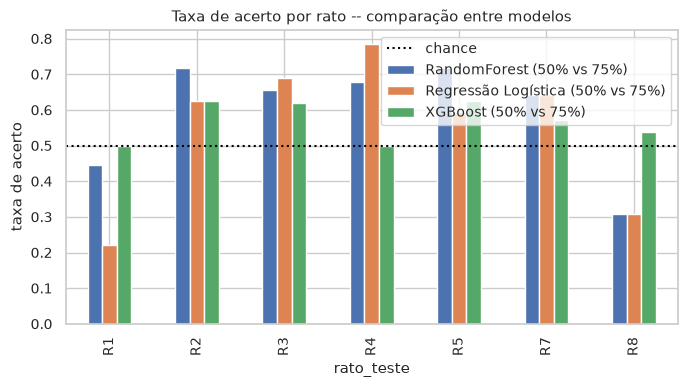


Rato(s) com desempenho abaixo da chance em TODOS os modelos:


,RandomForest (50% vs 75%),Regressão Logística (50% vs 75%),XGBoost (50% vs 75%),media_entre_modelos,consistentemente_pior
rato_teste,,,,,


In [24]:
dfs_por_rato = {}
for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    df_pred = saida["resultado"].get("df_predicoes_detalhadas", pd.DataFrame())
    if df_pred.empty:
        continue

    por_rato = df_pred.groupby("rato_teste").agg(
        n_amostras=("acerto", "size"),
        taxa_acerto=("acerto", "mean"),
    ).reset_index()
    por_rato["taxa_erro"] = 1 - por_rato["taxa_acerto"]

    media_geral = por_rato["taxa_acerto"].mean()
    dp_geral = por_rato["taxa_acerto"].std()
    por_rato["abaixo_da_media_1dp"] = por_rato["taxa_acerto"] < (media_geral - dp_geral)
    por_rato["abaixo_da_chance_50pct"] = por_rato["taxa_acerto"] < 0.5

    por_rato = por_rato.sort_values("taxa_acerto")
    dfs_por_rato[nome] = por_rato

    print(f"\n=== [{nome}] Desempenho por rato (ordenado do pior pro melhor) ===")
    display(por_rato.round(3))

    problematicos = por_rato[por_rato["abaixo_da_media_1dp"] | por_rato["abaixo_da_chance_50pct"]]
    if len(problematicos):
        print(f"Ratos sinalizados como problemáticos em [{nome}]: "
              f"{problematicos['rato_teste'].tolist()}")
    else:
        print(f"Nenhum rato muito abaixo dos demais em [{nome}].")

    por_rato.to_csv(
        pasta_multiclasse / f"10_5_desempenho_por_rato_{nome.split(' ')[0].lower()}.csv", index=False
    )

# O mesmo rato é problemático em TODOS os modelos?
if len(dfs_por_rato) > 1:
    taxa_acerto_por_rato_modelo = pd.DataFrame({
        nome: df.set_index("rato_teste")["taxa_acerto"] for nome, df in dfs_por_rato.items()
    })
    print("\n=== Taxa de acerto por rato, lado a lado entre modelos ===")
    display(taxa_acerto_por_rato_modelo.round(3))

    fig, ax = plt.subplots(figsize=(7, 4))
    taxa_acerto_por_rato_modelo.plot(kind="bar", ax=ax)
    ax.axhline(0.5, color="black", linestyle=":", label="chance")
    ax.set_ylabel("taxa de acerto")
    ax.set_title("Taxa de acerto por rato -- comparação entre modelos")
    ax.legend()
    plt.tight_layout()
    plt.show()

    taxa_acerto_por_rato_modelo["media_entre_modelos"] = taxa_acerto_por_rato_modelo.mean(axis=1)
    taxa_acerto_por_rato_modelo["consistentemente_pior"] = (
        taxa_acerto_por_rato_modelo.drop(columns="media_entre_modelos")
        .lt(0.5).all(axis=1)
    )
    print("\nRato(s) com desempenho abaixo da chance em TODOS os modelos:")
    display(taxa_acerto_por_rato_modelo[taxa_acerto_por_rato_modelo["consistentemente_pior"]])
    taxa_acerto_por_rato_modelo.to_csv(pasta_multiclasse / "10_5_taxa_acerto_por_rato_entre_modelos.csv")

### 10.6 Análise por feature / região cerebral

Duas fontes complementares:

- **Importância de features** (`df_importancias_por_fold`): média (± dp) da
  importância/coeficiente de cada feature ao longo dos folds externos --
  mostra o que o modelo mais usou. Como `area` entra como variável dummy
  (`area_XXX`), quando essas colunas aparecem no topo, isso indica que a
  *identidade da região* por si só ajuda a discriminar 50% vs 75%.
- **Taxa de acerto por região** (`df_predicoes_detalhadas`, coluna `area`):
  mostra diretamente em quais regiões o modelo mais acerta/erra -- isso é o
  que efetivamente responde "existe uma região cerebral que gera muitos
  erros?" / "existe uma região que melhora bastante a classificação?".


=== [RandomForest (50% vs 75%)] Top 20 features (média entre folds externos) ===


,importancia_media,importancia_dp
skewness_mean_40pct,0.1128,0.0765
skewness_max_100pct,0.0915,0.0791
skewness_max_40pct,0.0816,0.0527
theta_gamma_lento_ratio_min_20pct,0.0815,0.0466
skewness_min_60pct,0.0795,0.0587
skewness_std_80pct,0.0745,0.0879
skewness_media_geral,0.0680,NaN
skewness_std_60pct,0.0679,0.0233
pot_theta_min_20pct,0.0581,0.0499
delta_theta_ratio_mean_80pct,0.0539,NaN


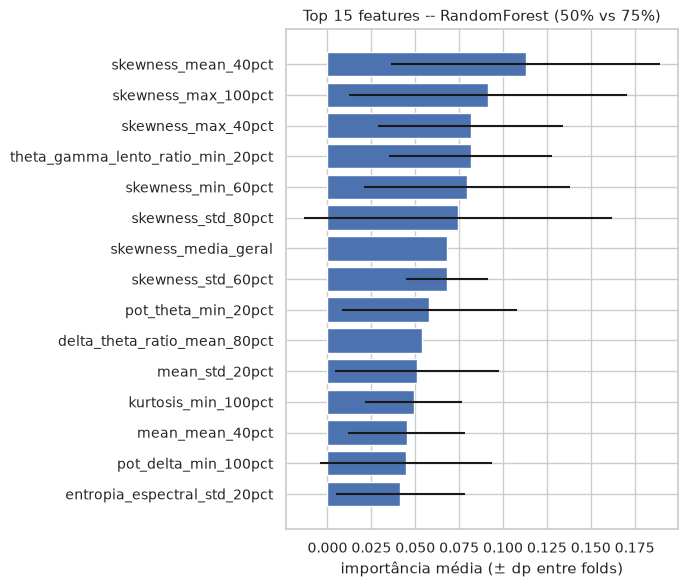

[RandomForest (50% vs 75%)] features usadas em 100% dos folds externos (top 10):


,fracao_dos_folds
skewness_max_40pct,1.000000
skewness_mean_40pct,1.000000
theta_gamma_lento_ratio_min_20pct,1.000000
skewness_max_100pct,1.000000
skewness_min_60pct,0.857143
kurtosis_min_100pct,0.714286
skewness_std_60pct,0.714286
pot_theta_min_20pct,0.714286
mean_mean_40pct,0.571429
mean_median_20pct,0.571429



=== [Regressão Logística (50% vs 75%)] Top 20 features (média entre folds externos) ===


,importancia_media,importancia_dp
pot_theta_min_80pct,1.0274,1.4380
theta_gamma_rapido_ratio_min_60pct,0.7743,1.0951
pot_theta_min_20pct,0.6607,0.7249
mean_median_20pct,0.6550,0.7018
skewness_media_geral,0.5561,0.7864
skewness_std_100pct,0.5316,0.7518
skewness_mean_40pct,0.5189,0.4370
mean_mean_20pct,0.4782,0.5190
kurtosis_min_100pct,0.4716,0.3113
skewness_max_100pct,0.4670,0.4771


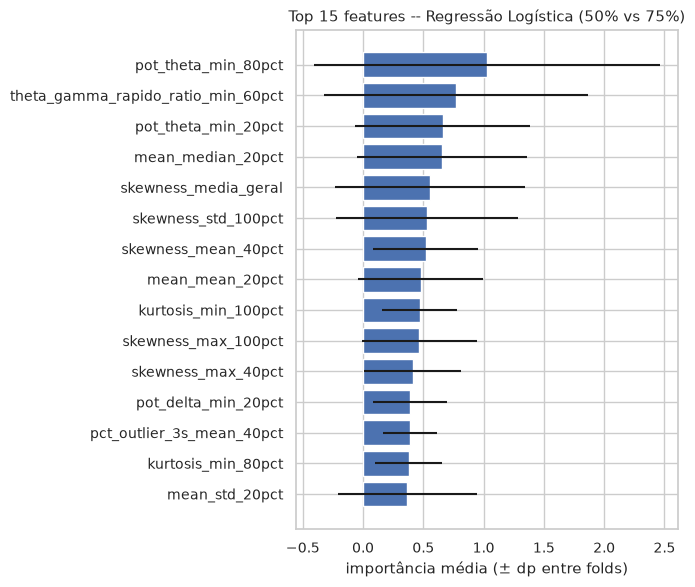

[Regressão Logística (50% vs 75%)] features usadas em 100% dos folds externos (top 10):


,fracao_dos_folds
mean_std_20pct,1.000000
skewness_max_40pct,1.000000
theta_gamma_lento_ratio_min_20pct,1.000000
skewness_mean_40pct,1.000000
skewness_max_100pct,1.000000
skewness_std_60pct,0.857143
skewness_min_60pct,0.857143
pot_delta_min_100pct,0.714286
mean_mean_40pct,0.714286
mean_median_20pct,0.714286



=== [XGBoost (50% vs 75%)] Top 20 features (média entre folds externos) ===


,importancia_media,importancia_dp
skewness_mean_40pct,0.1566,0.0590
skewness_min_60pct,0.1246,0.0593
mean_median_20pct,0.1209,0.1067
theta_gamma_lento_ratio_min_20pct,0.1180,0.0266
skewness_max_100pct,0.1094,0.0476
kurtosis_min_100pct,0.1074,0.0654
pot_delta_min_100pct,0.1058,0.0034
kurtosis_min_80pct,0.1045,0.0725
skewness_max_40pct,0.0981,0.0516
skewness_std_60pct,0.0902,0.0371


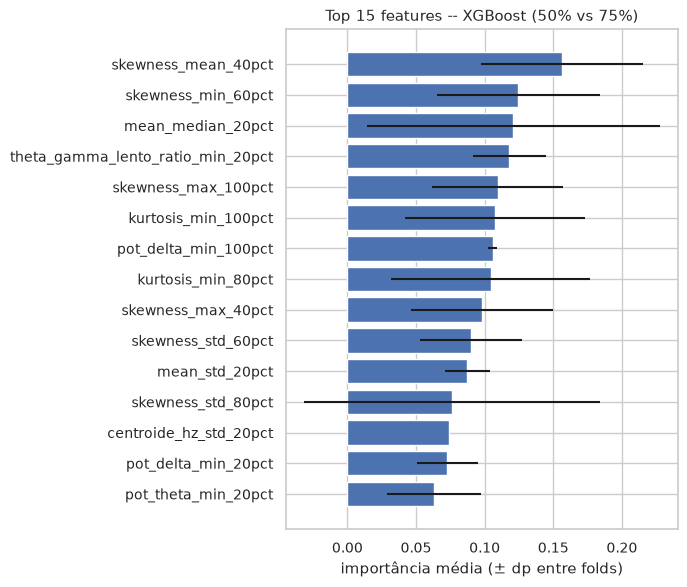

[XGBoost (50% vs 75%)] features usadas em 100% dos folds externos (top 10):


,fracao_dos_folds
skewness_mean_40pct,1.000000
skewness_max_40pct,1.000000
skewness_max_100pct,0.857143
theta_gamma_lento_ratio_min_20pct,0.857143
skewness_std_60pct,0.714286
skewness_min_60pct,0.714286
kurtosis_min_100pct,0.571429
kurtosis_min_80pct,0.428571
pot_theta_min_20pct,0.428571
mean_median_20pct,0.428571


In [25]:
TOP_N_IMPORTANCIA = 20
resumo_importancias = {}

for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    df_imp = saida["resultado"].get("df_importancias_por_fold", pd.DataFrame())
    if df_imp.empty:
        print(f"[{nome}] sem importâncias registradas -- pulando.")
        continue

    media_imp = df_imp.mean(axis=0).sort_values(ascending=False)
    dp_imp = df_imp.std(axis=0)
    resumo = pd.DataFrame({"importancia_media": media_imp, "importancia_dp": dp_imp.reindex(media_imp.index)})
    resumo_importancias[nome] = resumo

    print(f"\n=== [{nome}] Top {TOP_N_IMPORTANCIA} features (média entre folds externos) ===")
    display(resumo.head(TOP_N_IMPORTANCIA).round(4))

    fig, ax = plt.subplots(figsize=(7, 6))
    top = resumo.head(15).iloc[::-1]
    ax.barh(top.index, top["importancia_media"], xerr=top["importancia_dp"], color="#4C72B0")
    ax.set_xlabel("importância média (± dp entre folds)")
    ax.set_title(f"Top 15 features -- {nome}")
    plt.tight_layout()
    plt.show()

    resumo.to_csv(pasta_multiclasse / f"10_6_importancia_features_{nome.split(' ')[0].lower()}.csv")

    # quantas vezes cada feature foi de fato usada (não-NaN) entre os folds
    frequencia_uso = df_imp.notna().mean(axis=0).sort_values(ascending=False)
    print(f"[{nome}] features usadas em 100% dos folds externos (top 10):")
    display(frequencia_uso.head(10).rename("fracao_dos_folds").to_frame())


=== [RandomForest (50% vs 75%)] Taxa de acerto por região cerebral ===


,n_amostras,taxa_acerto
area,,
DGV,42,0.571
CA3c,41,0.610
DGD,43,0.628
CA3b,40,0.725



=== [Regressão Logística (50% vs 75%)] Taxa de acerto por região cerebral ===


,n_amostras,taxa_acerto
area,,
DGV,42,0.524
CA3c,41,0.561
DGD,43,0.628
CA3b,40,0.650



=== [XGBoost (50% vs 75%)] Taxa de acerto por região cerebral ===


,n_amostras,taxa_acerto
area,,
DGV,42,0.476
CA3c,41,0.561
CA3b,40,0.625
DGD,43,0.651



=== Taxa de acerto por região, lado a lado entre modelos ===


,RandomForest (50% vs 75%),Regressão Logística (50% vs 75%),XGBoost (50% vs 75%)
area,,,
DGV,0.571,0.524,0.476
CA3c,0.610,0.561,0.561
DGD,0.628,0.628,0.651
CA3b,0.725,0.650,0.625


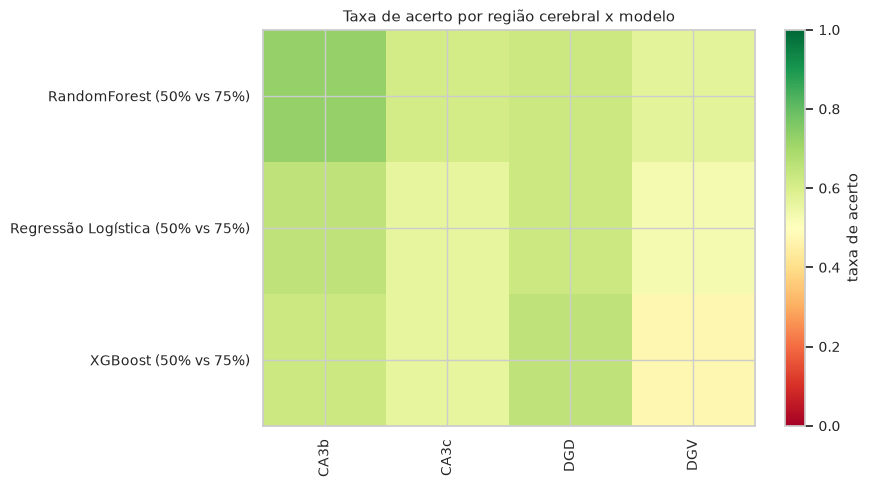


5 regiões com PIOR taxa de acerto média (entre modelos):


,taxa_acerto_media
area,
DGV,0.523810
CA3c,0.577236
DGD,0.635659
CA3b,0.666667



5 regiões com MELHOR taxa de acerto média (entre modelos):


,taxa_acerto_media
area,
CA3b,0.666667
DGD,0.635659
CA3c,0.577236
DGV,0.523810


In [26]:
# --- Taxa de acerto por área/região cerebral (independe de importância --
# é medida diretamente nos resultados de teste) ---
dfs_por_area = {}
for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    df_pred = saida["resultado"].get("df_predicoes_detalhadas", pd.DataFrame())
    if df_pred.empty:
        continue
    por_area = df_pred.groupby("area").agg(
        n_amostras=("acerto", "size"),
        taxa_acerto=("acerto", "mean"),
    ).sort_values("taxa_acerto")
    dfs_por_area[nome] = por_area
    print(f"\n=== [{nome}] Taxa de acerto por região cerebral ===")
    display(por_area.round(3))

if dfs_por_area:
    taxa_acerto_por_area_modelo = pd.DataFrame({
        nome: df["taxa_acerto"] for nome, df in dfs_por_area.items()
    })
    print("\n=== Taxa de acerto por região, lado a lado entre modelos ===")
    display(taxa_acerto_por_area_modelo.round(3).sort_values(
        taxa_acerto_por_area_modelo.columns[0]
    ))

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(taxa_acerto_por_area_modelo.T.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(taxa_acerto_por_area_modelo.index)))
    ax.set_xticklabels(taxa_acerto_por_area_modelo.index, rotation=90)
    ax.set_yticks(range(len(taxa_acerto_por_area_modelo.columns)))
    ax.set_yticklabels(taxa_acerto_por_area_modelo.columns)
    ax.set_title("Taxa de acerto por região cerebral x modelo")
    fig.colorbar(im, ax=ax, label="taxa de acerto")
    plt.tight_layout()
    plt.show()

    taxa_acerto_por_area_modelo.to_csv(pasta_multiclasse / "10_6_taxa_acerto_por_area_entre_modelos.csv")

    piores_regioes = taxa_acerto_por_area_modelo.mean(axis=1).sort_values().head(5)
    melhores_regioes = taxa_acerto_por_area_modelo.mean(axis=1).sort_values(ascending=False).head(5)
    print("\n5 regiões com PIOR taxa de acerto média (entre modelos):")
    display(piores_regioes.rename("taxa_acerto_media").to_frame())
    print("\n5 regiões com MELHOR taxa de acerto média (entre modelos):")
    display(melhores_regioes.rename("taxa_acerto_media").to_frame())

### 10.7 Cruzamento rato × região

Esta é a parte sugerida pela sua professora: cruza rato de teste com região
cerebral para achar *onde exatamente* um rato problemático está errando, se
esse problema é exclusivo dele ou se aparece em vários ratos, e se há alguma
região problemática **independente do rato**.


[RandomForest (50% vs 75%)] -- taxa de acerto por (rato x região)


area,CA3b,CA3c,DGD,DGV
rato_teste,,,,
R1,0.33,0.20,0.80,0.40
R2,0.75,1.00,0.62,0.50
R3,0.50,0.67,0.88,0.57
R4,0.86,0.57,0.57,0.71
R5,0.88,0.62,0.50,0.88
R7,0.50,0.75,0.75,0.50
R8,1.00,0.00,0.00,0.00


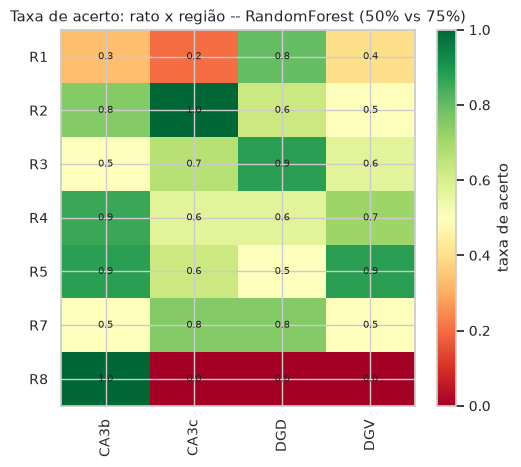

Rato com mais erros: R1 (10 erros)
Regiões onde R1 mais erra:


,n_erros
area,
CA3c,4
DGV,3
CA3b,2
DGD,1



Regiões com taxa de acerto < 50% em múltiplos ratos (quanto mais ratos, mais indício de problema estrutural na região, não no rato):


,n_ratos_com_baixo_desempenho_nessa_regiao
area,
CA3c,2
DGV,2
CA3b,1
DGD,1



[Regressão Logística (50% vs 75%)] -- taxa de acerto por (rato x região)


area,CA3b,CA3c,DGD,DGV
rato_teste,,,,
R1,0.00,0.00,0.60,0.20
R2,0.62,0.88,0.50,0.50
R3,0.50,0.67,0.88,0.71
R4,0.86,0.86,0.86,0.57
R5,0.75,0.38,0.62,0.62
R7,0.50,0.75,0.50,0.75
R8,1.00,0.00,0.00,0.00


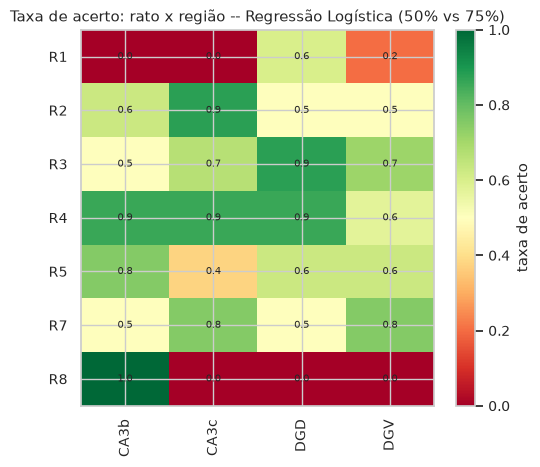

Rato com mais erros: R1 (14 erros)
Regiões onde R1 mais erra:


,n_erros
area,
CA3c,5
DGV,4
CA3b,3
DGD,2



Regiões com taxa de acerto < 50% em múltiplos ratos (quanto mais ratos, mais indício de problema estrutural na região, não no rato):


,n_ratos_com_baixo_desempenho_nessa_regiao
area,
CA3c,3
DGV,2
CA3b,1
DGD,1



[XGBoost (50% vs 75%)] -- taxa de acerto por (rato x região)


area,CA3b,CA3c,DGD,DGV
rato_teste,,,,
R1,0.33,0.60,0.80,0.20
R2,0.62,0.75,0.62,0.50
R3,0.50,0.67,0.88,0.43
R4,0.57,0.43,0.57,0.43
R5,0.75,0.50,0.50,0.75
R7,0.50,0.50,0.50,0.75
R8,1.00,0.33,0.67,0.00


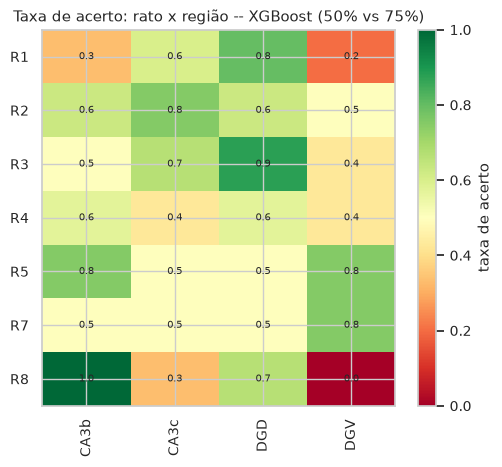

Rato com mais erros: R4 (14 erros)
Regiões onde R4 mais erra:


,n_erros
area,
CA3c,4
DGV,4
CA3b,3
DGD,3



Regiões com taxa de acerto < 50% em múltiplos ratos (quanto mais ratos, mais indício de problema estrutural na região, não no rato):


,n_ratos_com_baixo_desempenho_nessa_regiao
area,
DGV,4
CA3c,2
CA3b,1


In [27]:
for saida in saidas_disponiveis:
    nome = saida["nome_modelo"]
    df_pred = saida["resultado"].get("df_predicoes_detalhadas", pd.DataFrame())
    if df_pred.empty:
        continue

    pivot_taxa_acerto = df_pred.pivot_table(
        index="rato_teste", columns="area", values="acerto", aggfunc="mean"
    )
    pivot_n_amostras = df_pred.pivot_table(
        index="rato_teste", columns="area", values="acerto", aggfunc="size"
    )

    print(f"\n{'='*70}\n[{nome}] -- taxa de acerto por (rato x região)\n{'='*70}")
    display(pivot_taxa_acerto.round(2))

    fig, ax = plt.subplots(figsize=(0.55 * pivot_taxa_acerto.shape[1] + 3, 0.4 * pivot_taxa_acerto.shape[0] + 2))
    im = ax.imshow(pivot_taxa_acerto.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(pivot_taxa_acerto.shape[1])); ax.set_xticklabels(pivot_taxa_acerto.columns, rotation=90)
    ax.set_yticks(range(pivot_taxa_acerto.shape[0])); ax.set_yticklabels(pivot_taxa_acerto.index)
    for r in range(pivot_taxa_acerto.shape[0]):
        for c in range(pivot_taxa_acerto.shape[1]):
            val = pivot_taxa_acerto.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, f"{val:.1f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"Taxa de acerto: rato x região -- {nome}")
    fig.colorbar(im, ax=ax, label="taxa de acerto")
    plt.tight_layout()
    plt.show()

    # rato com mais erros no total
    erros_por_rato = df_pred[~df_pred["acerto"]].groupby("rato_teste").size().sort_values(ascending=False)
    if len(erros_por_rato):
        rato_mais_problematico = erros_por_rato.index[0]
        print(f"Rato com mais erros: {rato_mais_problematico} ({erros_por_rato.iloc[0]} erros)")

        # em qual região esse rato mais erra
        erros_desse_rato = df_pred[(df_pred['rato_teste'] == rato_mais_problematico) & (~df_pred['acerto'])]
        regioes_desse_rato = erros_desse_rato.groupby("area").size().sort_values(ascending=False)
        print(f"Regiões onde {rato_mais_problematico} mais erra:")
        display(regioes_desse_rato.rename("n_erros").to_frame())

    # regiões problemáticas de forma consistente (baixa taxa de acerto em VÁRIOS ratos,
    # não só em um único rato "ruim")
    limiar_baixo_desempenho = 0.5
    regiao_generalizada_ruim = (pivot_taxa_acerto < limiar_baixo_desempenho).sum(axis=0).sort_values(ascending=False)
    regiao_generalizada_ruim = regiao_generalizada_ruim[regiao_generalizada_ruim > 0]
    if len(regiao_generalizada_ruim):
        print(f"\nRegiões com taxa de acerto < {limiar_baixo_desempenho:.0%} em múltiplos ratos "
              f"(quanto mais ratos, mais indício de problema estrutural na região, não no rato):")
        display(regiao_generalizada_ruim.rename("n_ratos_com_baixo_desempenho_nessa_regiao").to_frame())
    else:
        print(f"\nNenhuma região ficou abaixo de {limiar_baixo_desempenho:.0%} de acerto em nenhum rato.")

    pivot_taxa_acerto.to_csv(pasta_multiclasse / f"10_7_rato_x_regiao_{nome.split(' ')[0].lower()}.csv")

### 10.8 Comparação entre modelos

Além do gráfico de barras já feito na Seção 9: os modelos erram nas mesmas
classes? Nos mesmos ratos? Usam as mesmas features importantes?

In [28]:
print("=== Melhor modelo (maior balanced_accuracy média por fold) ===")
display(df_desempenho_geral[["modelo", "balanced_accuracy_fold_media", "balanced_accuracy_fold_dp"]].head(1))

print("\n=== Modelo com menos erros totais (nível amostra) ===")
erros_totais = pd.DataFrame([
    {"modelo": nome, "n_erros_total": len(erros), "taxa_erro": len(erros) / len(saidas_disponiveis[i]['resultado']['df_predicoes_detalhadas'])}
    for i, (nome, erros) in enumerate(dfs_erros.items())
]).sort_values("n_erros_total")
display(erros_totais)

# sobreposicao de features mais importantes (top 15) entre modelos
if len(resumo_importancias) > 1:
    top15_por_modelo = {nome: set(r.head(15).index) for nome, r in resumo_importancias.items()}
    nomes_modelos = list(top15_por_modelo.keys())
    print("\n=== Sobreposição (Jaccard) das top-15 features entre modelos ===")
    linhas_jaccard = []
    for i in range(len(nomes_modelos)):
        for j in range(i + 1, len(nomes_modelos)):
            a, b = top15_por_modelo[nomes_modelos[i]], top15_por_modelo[nomes_modelos[j]]
            jaccard = len(a & b) / len(a | b) if (a | b) else np.nan
            linhas_jaccard.append({
                "modelo_a": nomes_modelos[i], "modelo_b": nomes_modelos[j],
                "features_em_comum": sorted(a & b), "n_em_comum": len(a & b), "jaccard": jaccard,
            })
    df_jaccard = pd.DataFrame(linhas_jaccard)
    display(df_jaccard[["modelo_a", "modelo_b", "n_em_comum", "jaccard"]])
    for _, linha in df_jaccard.iterrows():
        print(f"  {linha['modelo_a']} vs {linha['modelo_b']}: {linha['features_em_comum']}")
    df_jaccard.to_csv(pasta_multiclasse / "10_8_sobreposicao_features_entre_modelos.csv", index=False)

=== Melhor modelo (maior balanced_accuracy média por fold) ===


,modelo,balanced_accuracy_fold_media,balanced_accuracy_fold_dp
0,RandomForest (50% vs 75%),0.596458,0.140823



=== Modelo com menos erros totais (nível amostra) ===


,modelo,n_erros_total,taxa_erro
0,RandomForest (50% vs 75%),61,0.367470
1,Regressão Logística (50% vs 75%),68,0.409639
2,XGBoost (50% vs 75%),70,0.421687



=== Sobreposição (Jaccard) das top-15 features entre modelos ===


,modelo_a,modelo_b,n_em_comum,jaccard
0,RandomForest (50% vs 75%),Regressão Logística (50% vs 75%),7,0.304348
1,RandomForest (50% vs 75%),XGBoost (50% vs 75%),11,0.578947
2,Regressão Logística (50% vs 75%),XGBoost (50% vs 75%),9,0.428571


  RandomForest (50% vs 75%) vs Regressão Logística (50% vs 75%): ['kurtosis_min_100pct', 'mean_std_20pct', 'pot_theta_min_20pct', 'skewness_max_100pct', 'skewness_max_40pct', 'skewness_mean_40pct', 'skewness_media_geral']
  RandomForest (50% vs 75%) vs XGBoost (50% vs 75%): ['kurtosis_min_100pct', 'mean_std_20pct', 'pot_delta_min_100pct', 'pot_theta_min_20pct', 'skewness_max_100pct', 'skewness_max_40pct', 'skewness_mean_40pct', 'skewness_min_60pct', 'skewness_std_60pct', 'skewness_std_80pct', 'theta_gamma_lento_ratio_min_20pct']
  Regressão Logística (50% vs 75%) vs XGBoost (50% vs 75%): ['kurtosis_min_100pct', 'kurtosis_min_80pct', 'mean_median_20pct', 'mean_std_20pct', 'pot_delta_min_20pct', 'pot_theta_min_20pct', 'skewness_max_100pct', 'skewness_max_40pct', 'skewness_mean_40pct']


### 10.9 Comparação com a literatura

Esta parte é necessariamente qualitativa -- não dá pra "calcular"
concordância com a literatura, mas dá pra estruturar a comparação usando o
que você já levantou na tese e nos artigos do projeto (`AnaPaulaDeCastroAraujo_Tese.pdf`,
`fncel171144260.pdf`, `fnbeh16970083.pdf`).

**Contexto de partida (da tese, análise de c-Fos/grafos nas mesmas condições
de similaridade 25/50/75%):**

- As subregiões do hipocampo rostral (CA3aR, CA3bR, CA3cR, CA1R) e o Hilos
  (rostral, medial e caudal) aparecem repetidamente como *hubs* e como áreas
  com diferenças estatisticamente significativas entre condições de
  similaridade -- são boas candidatas a também aparecerem entre as
  regiões/features mais discriminativas do classificador LFP.
- O subículo (medial e caudal) e o CA3 medial aparecem como hubs
  especificamente nas condições de 50% e 75%, o que é diretamente relevante
  para este notebook (binário 50 vs 75%).
- No córtex, o PRH-36 (perirrinal, camada superficial) é a única região
  cortical fortemente engajada como hub na condição de 75%.
- Regiões corticais como LEC e PRH-35 aparecem com menos diferenças
  estatísticas entre condições na tese -- se elas também tiverem baixa
  importância/baixa taxa de acerto aqui, é um sinal de convergência.

**Preencha esta tabela depois de rodar as Seções 10.6-10.7 com os dados
reais:**

In [29]:
literatura_regioes_esperadas = {
    "CA3aR": "hub / diferença significativa entre condições (tese, c-Fos)",
    "CA3bR": "hub / diferença significativa entre condições (tese, c-Fos)",
    "CA3cR": "hub / diferença significativa entre condições (tese, c-Fos)",
    "HilosR": "hub em várias condições (tese, c-Fos)",
    "HilosM": "hub em várias condições (tese, c-Fos)",
    "HilosC": "hub, conecta hipocampo medial e córtex parahipocampal (tese)",
    "SubiculoM": "hub nas condições de 50% e 75% (tese, c-Fos)",
    "SubiculoC": "hub, conecta córtex parahipocampal ao hipocampo (tese)",
    "PRH-36S": "única área cortical fortemente engajada como hub em 75% (tese)",
}

linhas_comp_lit = []
if dfs_por_area:
    taxa_acerto_media_por_area = pd.DataFrame({
        nome: df["taxa_acerto"] for nome, df in dfs_por_area.items()
    }).mean(axis=1)
    for area, expectativa in literatura_regioes_esperadas.items():
        candidatas = [c for c in taxa_acerto_media_por_area.index if area.lower() in str(c).lower()]
        taxa_obs = taxa_acerto_media_por_area[candidatas].mean() if candidatas else np.nan
        linhas_comp_lit.append({
            "regiao_esperada_pela_literatura": area,
            "papel_na_literatura": expectativa,
            "colunas_correspondentes_no_dataset": candidatas,
            "taxa_acerto_media_observada": taxa_obs,
        })

df_comp_literatura = pd.DataFrame(linhas_comp_lit)
print("=== Comparação: regiões destacadas na literatura (tese) vs. taxa de acerto observada ===")
print("(taxa de acerto ALTA nessas regiões é consistente com a hipótese de que elas carregam")
print(" sinal relevante para diferenciar 50% vs 75%; taxa BAIXA ou nula sugere divergência)")
display(df_comp_literatura)
df_comp_literatura.to_csv(pasta_multiclasse / "10_9_comparacao_literatura.csv", index=False)

print(
    "\nPerguntas-guia para preencher manualmente após inspecionar os resultados acima e os artigos:\n"
    "  - Os resultados concordam com os artigos publicados (tese + fncel171144260 + fnbeh16970083)?\n"
    "  - As regiões mais importantes para o classificador (Seção 10.6) coincidem com os hubs/áreas\n"
    "    de diferença significativa da tese (CA3, Hilos, Subículo, PRH-36)?\n"
    "  - Se houver divergência, ela pode ser explicada por: (a) o classificador usar sinal de LFP\n"
    "    (potência espectral, PAC) em vez de expressão de c-Fos -- são medidas de naturezas diferentes\n"
    "    (atividade elétrica vs. imediato-precoce/plasticidade); (b) diferença de tarefa/condição\n"
    "    comparada (aqui é só 50% vs 75%, a tese compara também com NOR/DIST/25%); (c) tamanho\n"
    "    amostral (poucos ratos por fold externo).\n"
    "  - O comportamento observado (ex.: qual região mais discrimina 50% de 75%) já foi descrito\n"
    "    antes na literatura de LFP/PAC em hipocampo, mesmo que não nesta tese especificamente?"
)

=== Comparação: regiões destacadas na literatura (tese) vs. taxa de acerto observada ===
(taxa de acerto ALTA nessas regiões é consistente com a hipótese de que elas carregam
 sinal relevante para diferenciar 50% vs 75%; taxa BAIXA ou nula sugere divergência)


,regiao_esperada_pela_literatura,papel_na_literatura,colunas_correspondentes_no_dataset,taxa_acerto_media_observada
0,CA3aR,hub / diferença significativa entre condições ...,[],NaN
1,CA3bR,hub / diferença significativa entre condições ...,[],NaN
2,CA3cR,hub / diferença significativa entre condições ...,[],NaN
3,HilosR,"hub em várias condições (tese, c-Fos)",[],NaN
4,HilosM,"hub em várias condições (tese, c-Fos)",[],NaN
5,HilosC,"hub, conecta hipocampo medial e córtex parahip...",[],NaN
6,SubiculoM,"hub nas condições de 50% e 75% (tese, c-Fos)",[],NaN
7,SubiculoC,"hub, conecta córtex parahipocampal ao hipocamp...",[],NaN
8,PRH-36S,única área cortical fortemente engajada como h...,[],NaN



Perguntas-guia para preencher manualmente após inspecionar os resultados acima e os artigos:
  - Os resultados concordam com os artigos publicados (tese + fncel171144260 + fnbeh16970083)?
  - As regiões mais importantes para o classificador (Seção 10.6) coincidem com os hubs/áreas
    de diferença significativa da tese (CA3, Hilos, Subículo, PRH-36)?
  - Se houver divergência, ela pode ser explicada por: (a) o classificador usar sinal de LFP
    (potência espectral, PAC) em vez de expressão de c-Fos -- são medidas de naturezas diferentes
    (atividade elétrica vs. imediato-precoce/plasticidade); (b) diferença de tarefa/condição
    comparada (aqui é só 50% vs 75%, a tese compara também com NOR/DIST/25%); (c) tamanho
    amostral (poucos ratos por fold externo).
  - O comportamento observado (ex.: qual região mais discrimina 50% de 75%) já foi descrito
    antes na literatura de LFP/PAC em hipocampo, mesmo que não nesta tese especificamente?


### 10.10 Resumo executivo -- respostas às perguntas-guia

Célula final: monta automaticamente um resumo em texto respondendo às
perguntas que você listou, a partir de tudo que foi calculado acima. Rode por
último, depois de todas as seções 10.1-10.9.

In [30]:
print("#" * 70)
print("# RESUMO EXECUTIVO")
print("#" * 70)

melhor_modelo_linha = df_desempenho_geral.iloc[0]
print(f"\n1) Qual modelo foi o melhor?\n   -> {melhor_modelo_linha['modelo']} "
      f"(balanced_accuracy = {melhor_modelo_linha['balanced_accuracy_fold_media']:.3f} "
      f"± {melhor_modelo_linha['balanced_accuracy_fold_dp']:.3f}, média entre folds/ratos)")

if 'df_matriz_por_classe' in globals() and not df_matriz_por_classe.empty:
    pior_classe_geral = (
        df_matriz_por_classe.groupby("classe_real")["taxa_acerto_classe"].mean().idxmin()
    )
    print(f"\n2) Onde os modelos erram (qual classe)?\n   -> Em geral, mais na classe '{pior_classe_geral}'.")

if dfs_por_area:
    print(f"\n2b) Onde os modelos erram (qual região)?\n   -> Regiões com menor taxa de acerto média: "
          f"{list(taxa_acerto_por_area_modelo.mean(axis=1).sort_values().head(3).index)}")
    print(f"\n3) Onde os modelos acertam (qual região)?\n   -> Regiões com maior taxa de acerto média: "
          f"{list(taxa_acerto_por_area_modelo.mean(axis=1).sort_values(ascending=False).head(3).index)}")

if len(dfs_por_rato) > 1 and 'taxa_acerto_por_rato_modelo' in globals():
    ratos_problematicos = taxa_acerto_por_rato_modelo.index[
        taxa_acerto_por_rato_modelo.get('consistentemente_pior', pd.Series(False, index=taxa_acerto_por_rato_modelo.index))
    ].tolist()
    print(f"\n5/6) Existe rato problemático em TODOS os modelos?\n   -> "
          f"{ratos_problematicos if ratos_problematicos else 'Nenhum rato ficou abaixo da chance em todos os modelos.'}")

print(f"\n8) Existe padrão de erro? / região consistentemente difícil?")
print("   -> Ver tabela 'regiao_generalizada_ruim' impressa na Seção 10.7 para cada modelo:")
print("      regiões com taxa de acerto < 50% em vários ratos ao mesmo tempo são as mais")
print("      fortes candidatas a serem 'estruturalmente' difíceis (não um problema de um rato só).")

print(f"\n10) Compatibilidade com a literatura:\n   -> Ver tabela df_comp_literatura (Seção 10.9) e")
print("      preencher a interpretação qualitativa com base nela e nos PDFs do projeto.")

print("\n" + "#" * 70)
print("# Todas as tabelas usadas aqui foram salvas em:", pasta_multiclasse.resolve())
print("#" * 70)

######################################################################
# RESUMO EXECUTIVO
######################################################################

1) Qual modelo foi o melhor?
   -> RandomForest (50% vs 75%) (balanced_accuracy = 0.596 ± 0.141, média entre folds/ratos)

2) Onde os modelos erram (qual classe)?
   -> Em geral, mais na classe '50%'.

2b) Onde os modelos erram (qual região)?
   -> Regiões com menor taxa de acerto média: ['DGV', 'CA3c', 'DGD']

3) Onde os modelos acertam (qual região)?
   -> Regiões com maior taxa de acerto média: ['CA3b', 'DGD', 'CA3c']

5/6) Existe rato problemático em TODOS os modelos?
   -> Nenhum rato ficou abaixo da chance em todos os modelos.

8) Existe padrão de erro? / região consistentemente difícil?
   -> Ver tabela 'regiao_generalizada_ruim' impressa na Seção 10.7 para cada modelo:
      regiões com taxa de acerto < 50% em vários ratos ao mesmo tempo são as mais
      fortes candidatas a serem 'estruturalmente' difíceis (não um pro